# 15 · Model Yorumlanabilirliği (Model Interpretability)

> **Bu notebook'ta ne öğreneceğiz?**
> Bir modelin "ne kadar iyi" tahmin ettiğini önceki notebook'ta (11 · Model Değerlendirme
> Metrikleri) ölçmüştük; bu notebook ise modelin **NEDEN** o tahmini yaptığını açıklamayı
> öğretiyor. Model-agnostik (Permutation Importance, Partial Dependence/ICE, LIME, SHAP
> KernelExplainer) ve model-spesifik (SHAP TreeExplainer, SHAP LinearExplainer) yöntemleri;
> global (modelin genel davranışı) ve local (tek bir tahminin açıklaması) yorumlanabilirlik
> ayrımını; ve korelasyonlu özniteliklerin bu yöntemleri nasıl yanıltabileceğini ele alacağız.
> Bu, kategori D'nin (Model Değerlendirme ve İyileştirme) son notebook'u.
>
> **Önkoşul:** 07-10 (ağaç tabanlı modeller, MDI feature importance), 11 (model değerlendirme
> metrikleri).
> **Veri:** ISLR `Default` (kredi temerrüdü, ikili sınıflandırma), ISLR `Hitters` (beyzbol
> maaş tahmini, regresyon), `Mroz` (kadın işgücüne katılımı, ikili sınıflandırma).
> **Araçlar:** scikit-learn (`permutation_importance`, `PartialDependenceDisplay`), `shap`,
> `lime`, R (`iml`, `pdp`), DuckDB.

## 1 · Yorumlanabilirlik Neden Önemli?

Bir modelin doğruluğu (accuracy, AUC, RMSE...) yeterli olsaydı, "kara kutu" (black-box)
modelleri sorgusuzca üretime almak yeterli olurdu. Ama pratikte üç ayrı ihtiyaç ortaya çıkar:

1. **Güven ve hata ayıklama (debugging):** Model yüksek doğruluk verse bile, bunu **yanlış
   nedenlerle** yapıyor olabilir (bkz. 08 · Decision Trees'teki `casual+registered=cnt`
   sızıntı örneği, veya 14'teki `AER::CreditCard` sızıntısı). Yorumlanabilirlik araçları bu
   tür sızıntıları modelin *içine bakarak* yakalamayı sağlar.
2. **Düzenleyici/hukuki zorunluluk:** ABD'de **ECOA (Equal Credit Opportunity Act)**, bir
   kredi başvurusu reddedildiğinde bankanın somut, spesifik ret gerekçelerini ("adverse
   action notice") başvurana bildirmesini zorunlu kılar — "modelimiz reddetti" yeterli
   değildir. AB'de [**GDPR Madde 22**](https://gdpr-info.eu/art-22-gdpr/), otomatik kararlara karşı "anlamlı bilgi alma" hakkı
   tanır. [KVKK'da](https://dergipark.org.tr/tr/pub/kvkd/article/1974807) ise 6698 sayılı Kişisel Verilerin Korunması Kanunu’nun (6698 sayılı Kanun) 11. maddesinin birinci fıkrasının (g) bendi, herkesin işlenen verilerinin münhasıran otomatik sistemler vasıtasıyla analiz edilmesi suretiyle kendi aleyhine bir sonuç çıkmasına itiraz etme hakkını tanımaktadır. SHAP/LIME gibi araçlar bu tür somut, kişiye özel (*local*) açıklamaları üretmek
   için endüstride fiilen kullanılır (örn. FICO, çeşitli fintech kredi skorlama sistemleri).
3. **Bilimsel/akademik raporlama:** Bir makalede "modelimiz %94 doğruluk elde etti" demek
   yeterli değildir; hangi değişkenlerin, ne yönde ve ne büyüklükte etkili olduğunu
   göstermek (feature importance tabloları, PDP grafikleri, SHAP summary plot'ları)
   çoğu dergi/konferansın (ör. tıp, ekonomi, sosyal bilim dergileri) yayın standardı
   haline gelmiştir.

**Endüstride diğer örnekler:** Sağlıkta klinik karar destek sistemlerinin bir hastayı
"yüksek risk" olarak işaretlemesinin hangi klinik değişkenlere dayandığının hekime
gösterilmesi (LIME'ın orijinal makalesindeki motive edici örneklerden biri budur);
savunma ve otonom sistemlerde bir sınıflandırıcının kararının denetlenebilir/izlenebilir
olması (audit trail) gereksinimi; enerji sektöründe bir talep tahmini modelinin hangi
hava durumu/takvim değişkenlerine duyarlı olduğunun operasyon ekiplerine açıklanması.

## 2 · Taksonomi: Model-Spesifik / Model-Agnostik, Global / Local

| Eksen | Seçenek 1 | Seçenek 2 |
|---|---|---|
| **Bağımlılık** | Model-spesifik (ör. karar ağacının kendi `feature_importances_`'ı, SHAP `TreeExplainer`) — hızlı ama sadece o model ailesi için | Model-agnostik (Permutation Importance, PDP, LIME, SHAP `KernelExplainer`) — herhangi bir `predict`/`predict_proba` fonksiyonuna uygulanabilir, ama genelde daha yavaş |
| **Kapsam** | **Global** — modelin genel davranışını özetler ("balance değişkeni en önemli özellik") | **Local** — tek bir tahmini açıklar ("bu müşteri, bakiyesi 2100$ olduğu için %80 temerrüt olasılığına sahip") |

Bu notebook'ta ele alacağımız yöntemler bu tabloda şu şekilde konumlanır: Permutation
Importance (model-agnostik, global), PDP/ICE (model-agnostik, global + yarı-local), LIME
(model-agnostik, local), SHAP (hem model-spesifik hem agnostik varyantları var, hem
global — summary plot — hem local — waterfall/force plot — kullanılabilir; SHAP aslında
bu tabloda **her iki eksende de** köprü kurduğu için özel bir yere sahiptir).

## 3 · Permutation Feature Importance

**Fikir:** Bir özniteliğin gerçekten önemli olup olmadığını anlamanın en doğrudan yolu, o
özniteliğin değerlerini **rastgele karıştırmak** (permute etmek) ve modelin performansının
ne kadar düştüğüne bakmaktır. Eğer $X_j$ önemliyse, karıştırıldığında model performansı
ciddi düşer; önemsizse neredeyse hiç değişmez.

$$\text{PI}_j = s - \frac{1}{K}\sum_{k=1}^{K} s_{j,\pi_k}$$

burada $s$ orijinal test-seti skoru (ör. accuracy, $R^2$), $s_{j,\pi_k}$ ise $j$. özniteliğin
$k$. rastgele permütasyonuyla elde edilen skor, $K$ tekrar sayısıdır (varyansı azaltmak için
genelde $K\geq 5$ önerilir).

**08-10'daki MDI (Mean Decrease in Impurity) ile farkı:** MDI, sadece ağaç tabanlı modellerde
mevcut, eğitim verisi üzerinde hesaplanan model-içi (dolayısıyla eğitim setine "sızıntılı"
ve yüksek-kardinaliteli/sürekli özniteliklere yanlı) bir ölçüttür. Permutation Importance
**herhangi bir model için**, tercihen **test/holdout verisi üzerinde** hesaplanır — bu yüzden
gerçek genelleme katkısını yansıtır ve kardinalite yanlılığı taşımaz.

**Kritik tuzak — korelasyonlu öznitelikler:** İki öznitelik ($X_1, X_2$) güçlü korelasyonlu
ise, $X_1$'i karıştırmak modelin performansını fazla düşürmez, çünkü model hâlâ $X_2$
üzerinden aynı bilgiye erişebilir — bu, $X_1$'in *aslında önemsiz* olduğu anlamına gelmez,
sadece *yedekli (redundant)* bilgi taşıdığı anlamına gelir. Bu notebook'ta `Hitters`
veri setinin kariyer istatistikleri (`CAtBat`, `CHits`, `CRuns`, `CRBI`, `CWalks` — hepsi
oyuncunun kariyer uzunluğuyla güçlü korelasyonlu) üzerinde bu tuzağı somut olarak
göstereceğiz.

**Endüstride kullanımı:** Kredi skorlama modellerinin düzenleyici denetimi sırasında,
bankalar hangi değişkenlerin modelin kararına gerçekten katkı sağladığını (ve örneğin
yasak olan dolaylı ayrımcılık proxy'lerinin katkı sağlamadığını) kanıtlamak için genellikle
permutation importance kullanır — çünkü model-agnostiktir ve düzenleyiciye "bu model
ailesine özgü değil, genel bir istatistiksel test" diye sunulabilir.

## 4 · Partial Dependence Plot (PDP) ve Individual Conditional Expectation (ICE)

**PDP fikri:** Bir özniteliğin ($X_S$) tahmine olan **marjinal etkisini**, diğer tüm
öznitelikleri ($X_C$) gözlemlenen dağılımları üzerinden ortalayarak izole eder:

$$\hat{f}_S(x_S) = \frac{1}{n}\sum_{i=1}^{n} \hat{f}(x_S, x_C^{(i)})$$

Yani $X_S$'i sabit bir $x_S$ değerine sabitleyip, veri kümesindeki **her** gözlemin diğer
tüm özniteliklerini olduğu gibi bırakarak tahmin üretir ve bu tahminlerin ortalamasını alır.
Bu işlem $x_S$'in bir ızgarası (grid) üzerinde tekrarlanarak eğri çizilir.

**ICE (Individual Conditional Expectation):** PDP, $n$ tane bireysel eğrinin (her gözlem
için ayrı ayrı $\hat{f}(x_S, x_C^{(i)})$ eğrisi) **ortalamasıdır**. ICE bu $n$ eğriyi tek
tek çizer — PDP'nin gizlediği **heterojenliği** (ör. bazı gözlemlerde $X_S$ artınca tahmin
artarken, başka bir alt-grupta tam tersi olması, yani bir **etkileşim** varlığı) ortaya
çıkarır.

**Varsayım ve tuzak:** PDP, $X_S$ ile $X_C$'nin **bağımsız** olduğunu varsayar — $x_S$'i
sabitlerken $x_C$'yi olduğu gibi bırakmak, eğer $X_S$ ile $X_C$ güçlü korelasyonluysa,
**gerçekte hiç var olmayan/gözlemlenmemiş** kombinasyonlar için ekstrapolasyon yapmak
anlamına gelir (ör. `Hitters`'ta çok yüksek `CAtBat` ama çok düşük `Years` — pratikte
imkânsız bir kombinasyon — için tahmin üretmek).

**Endüstride kullanımı:** Sigortacılıkta (bkz. 04 · GLM ailesi notebook'u) bir prim
modelinin yaşa göre nasıl değiştiğini (diğer risk faktörleri sabitken) grafiksel olarak
düzenleyiciye ve poliçe sahiplerine göstermek — PDP, bu "diğer her şey sabitken" hikayesini
tam olarak görselleştirir.

## 5 · LIME (Local Interpretable Model-agnostic Explanations)

**Fikir (Ribeiro, Singh & Guestrin, 2016):** Karmaşık bir modelin **global** davranışını
basit bir modelle taklit etmek genelde imkânsızdır, ama modelin karar sınırı **tek bir
noktanın (açıklanacak örneğin) çok yakın komşuluğunda yerel olarak neredeyse lineerdir**
varsayımıyla yola çıkılır. LIME şu adımları izler:

1. Açıklanacak örnek $x$ etrafında, özniteliklerini rastgele bozarak (perturbation) sentetik
   komşu örnekler üretir.
2. Bu komşuların gerçek modelden $\hat{f}$ tahminlerini alır.
3. Komşuları, $x$'e olan uzaklıklarına göre ağırlıklandırıp ($\pi_x$ kernel ağırlığı — $x$'e
   yakın komşular daha çok ağırlık alır), üzerlerine **basit, yorumlanabilir bir model**
   (genelde $L_1$-cezalı lineer regresyon) eğitir:

$$\xi(x) = \arg\min_{g \in G} \; \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

burada $\mathcal{L}$ ağırlıklı sadakat kaybı (yerel modelin gerçek modeli ne kadar iyi
taklit ettiği), $\Omega(g)$ yerel modelin karmaşıklığına ceza (ör. kaç öznitelik
kullandığı).

4. Bu yerel lineer modelin katsayıları, $x$ için "her özniteliğin bu spesifik tahmine
   katkısı" olarak yorumlanır.

**Kritik sınırlama:** LIME'ın komşuluk tanımı (perturbation dağılımı, kernel genişliği)
kullanıcı tarafından seçilir ve sonuç bu seçime **duyarlıdır** — aynı örnek için farklı
rastgele tohumlarla (seed) çalıştırıldığında açıklamalar hafifçe değişebilir (SHAP'ın aksine
LIME'ın teorik bir "tutarlılık" garantisi yoktur).

**Endüstride kullanımı:** Sağlıkta bir hastane yeniden-yatış (readmission) riski modelinin
belirli bir hastayı neden yüksek riskli işaretlediğini hekime tek bir vaka üzerinden
göstermek (LIME'ın orijinal makalesinin motive edici örneklerinden biri).

## 6 · SHAP (SHapley Additive exPlanations)

**Kökeni — Shapley değerleri (kooperatif oyun teorisi, Shapley 1953):** $n$ oyuncunun
(özniteliklerin) bir "oyuna" (tahmine) toplu katkısını, her oyuncunun **tüm olası
koalisyonlara (öznitelik alt kümelerine) katılma sıralarının ortalaması** üzerinden adil
şekilde paylaştırır:

$$\phi_j = \sum_{S \subseteq \{1,\dots,p\}\setminus\{j\}} \frac{|S|!\,(p-|S|-1)!}{p!} \Big[f(S\cup\{j\}) - f(S)\Big]$$

Bu formül dört aksiyomu (Efficiency/toplamı $\hat{f}(x)-E[\hat{f}(X)]$'e eşitlik,
Symmetry, Dummy, Additivity) **tek şekilde** sağlayan **tek** paylaşım yöntemidir — SHAP'ın
LIME'a göre en büyük teorik avantajı budur: **toplanabilirlik** garantisi sayesinde bir
tahminin SHAP değerleri toplamı + baz değer ($E[\hat f(X)]$) = o tahminin kendisine tam
eşittir.

**Pratikte üç ana SHAP hesaplayıcısı (Explainer):**

| Explainer | Ne zaman kullanılır | Hız |
|---|---|---|
| `TreeExplainer` | Karar ağacı/RF/GBM/XGBoost/LightGBM/CatBoost | Çok hızlı, **kesin** (polinomsal algoritma, örnekleme gerektirmez) |
| `LinearExplainer` | Lineer/Lojistik Regresyon | Çok hızlı, **kesin** (katsayı × (öznitelik − ortalama) kapalı-form) |
| `KernelExplainer` | Herhangi bir model (model-agnostik) | Yavaş — LIME'a benzer ağırlıklı-örnekleme yaklaşımı kullanır, **yaklaşık** |

**Görselleştirmeler:** *Summary/beeswarm plot* (global: her öznitelik için tüm örneklerin
SHAP değerleri, öznitelik değeriyle renklendirilmiş — hem önem sıralaması hem yön/etkileşim
bilgisi verir), *bar plot* (global: ortalama |SHAP| değeri, MDI/permutation importance'a en
yakın sunum), *waterfall/force plot* (local: tek bir tahminin baz değerden nasıl
"parça parça" o tahmine ulaştığı), *dependence plot* (bir özniteliğin SHAP değerinin, o
özniteliğin kendi değerine göre dağılımı — renk kodlamasıyla ikinci bir özniteliğin
etkileşimi de gösterilebilir).

**Endüstride kullanımı:** ECOA/GDPR kapsamındaki "adverse action" gerekçelendirmesi için
fintech kredi skorlama modellerinde (additivity garantisi sayesinde "bu üç neden toplamda
skorunuzu tam olarak 40 puan düşürdü" gibi denetlenebilir, sayısal olarak tutarlı
açıklamalar üretilebiliyor); Kaggle yarışmalarında model hata ayıklama ve öznitelik
mühendisliği fikirleri üretmek için yaygın standart araç.

## 7 · Yöntem Karşılaştırması ve Ortak Tuzaklar

| Yöntem | Kapsam | Model bağımlılığı | Hız | Teorik garanti |
|---|---|---|---|---|
| Permutation Importance | Global | Agnostik | Orta (K tekrar × p öznitelik) | Yok (varyanslı, korelasyona duyarlı) |
| PDP / ICE | Global (+ heterojenlik) | Agnostik | Orta (grid × n) | Yok (bağımsızlık varsayımı) |
| LIME | Local | Agnostik | Hızlı (tek örnek) | Yok (perturbation seçimine duyarlı) |
| SHAP (Tree/Linear) | Global + Local | Spesifik | Çok hızlı, kesin | Var (tek Shapley aksiyomları) |
| SHAP (Kernel) | Global + Local | Agnostik | Yavaş, yaklaşık | Var (asimptotik olarak) |

Ortak tuzak, hepsinin bir şekilde etkilendiği **korelasyonlu öznitelikler** sorunudur —
bu notebook'ta `Hitters` kariyer istatistikleri üzerinden Adım 12'de somut olarak
göstereceğiz.

# 🐍 Python Uygulaması

Adımlar:
1. Ortam kurulumu ve üç veri setinin yüklenmesi
2. Baseline modellerin eğitimi (Default: Lojistik Regresyon + Random Forest, Hitters:
   Random Forest Regressor, Mroz: Lojistik Regresyon + Random Forest)
3. Model-içi (built-in) önem ölçütlerinin hatırlatılması (katsayılar, MDI)
4. Permutation Feature Importance
5. Partial Dependence Plot (1D)
6. 2D PDP ve ICE (heterojenlik/etkileşim)
7. LIME ile yerel açıklama
8. SHAP TreeExplainer (global + local)
9. SHAP LinearExplainer ve KernelExplainer
10. SHAP dependence plot ve etkileşim
11. Yöntemler arası karşılaştırma (MDI vs Permutation vs SHAP)
12. Korelasyonlu öznitelik tuzağı deneyi
13. Global vs Local özet ve yöntem seçim rehberi

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import roc_auc_score, r2_score, mean_absolute_error

import shap
import lime
import lime.lime_tabular

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

pd.set_option('display.max_columns', 30)
print('shap', shap.__version__)

shap 0.52.0


## Adım 1 · Veri Yükleme

**Ne yapıyoruz?** Üç gerçek veri setini yüklüyoruz:

- **`Default`** (James, Witten, Hastie & Tibshirani, *An Introduction to Statistical
  Learning*, ISLR paketi) — 10.000 kredi kartı müşterisi, ikili hedef `default` (temerrüt
  edip etmediği), öznitelikler: `student` (öğrenci mi), `balance` (aylık ortalama bakiye),
  `income` (yıllık gelir). Sınıflar dengesiz (%3.3 temerrüt).
- **`Hitters`** (ISLR paketi, orijinal kaynak: 1986-87 MLB sezonu, StatLib/ASA veri
  arşivi) — 322 profesyonel beyzbol oyuncusu, hedef `Salary` (1987 maaşı, bin $), 19
  sayısal/kategorik kariyer istatistiği (`AtBat`, `Hits`, `CRuns`, `CRBI`, `League`,
  `Division`...). **59 satırda `Salary` eksik** — bunlar atılacak.
- **`Mroz`** (Mroz, T.A. 1987, *Econometrica* — 1975 PSID (Panel Study of Income
  Dynamics) anketi, `carData` R paketi) — 753 evli kadın, ikili hedef `lfp` (labor force
  participation — işgücüne katılıp katılmadığı), öznitelikler: `k5`/`k618` (5 yaş
  altı/5-18 yaş arası çocuk sayısı), `age`, `wc`/`hc` (kadın/koca kolej mezunu mu),
  `lwg` (log ücret tahmini), `inc` (eş dışı aile geliri, bin $).

Üçü de bu serinin önceki notebook'larında **kullanılmamış** yeni veri setleri.

In [2]:
default_df = pd.read_csv('data/default.csv')
default_df['default'] = (default_df['default'] == 'Yes').astype(int)
default_df['student'] = (default_df['student'] == 'Yes').astype(float)
print('Default:', default_df.shape)
print(default_df['default'].value_counts(normalize=True).round(4))
default_df.head()

Default: (10000, 4)
default
0    0.9667
1    0.0333
Name: proportion, dtype: float64


,default,student,balance,income
0,0,0.0,729.526495,44361.625074
1,0,1.0,817.180407,12106.134700
2,0,0.0,1073.549164,31767.138947
3,0,0.0,529.250605,35704.493935
4,0,0.0,785.655883,38463.495879


In [3]:
hitters_df = pd.read_csv('data/hitters.csv').rename(columns={'rownames': 'Player'})
print('Hitters (ham):', hitters_df.shape, '| eksik Salary:', hitters_df['Salary'].isna().sum())
hitters_df = hitters_df.dropna(subset=['Salary']).reset_index(drop=True)
hitters_df['League'] = (hitters_df['League'] == 'A').astype(float)      # 1=American League
hitters_df['Division'] = (hitters_df['Division'] == 'E').astype(float)  # 1=East
hitters_df['NewLeague'] = (hitters_df['NewLeague'] == 'A').astype(float)
print('Hitters (Salary eksikleri atıldıktan sonra):', hitters_df.shape)
hitters_df.describe().T[['mean', 'std', 'min', 'max']].round(1)

Hitters (ham): (322, 20) | eksik Salary: 59
Hitters (Salary eksikleri atıldıktan sonra): (263, 20)


,mean,std,min,max
AtBat,403.6,147.3,19.0,687.0
Hits,107.8,45.1,1.0,238.0
HmRun,11.6,8.8,0.0,40.0
Runs,54.7,25.5,0.0,130.0
RBI,51.5,25.9,0.0,121.0
Walks,41.1,21.7,0.0,105.0
Years,7.3,4.8,1.0,24.0
CAtBat,2657.5,2286.6,19.0,14053.0
CHits,722.2,648.2,4.0,4256.0
CHmRun,69.2,82.2,0.0,548.0


In [4]:
mroz_df = pd.read_csv('data/mroz.csv')
mroz_df['lfp'] = (mroz_df['lfp'] == 'yes').astype(int)
mroz_df['wc'] = (mroz_df['wc'] == 'yes').astype(int)
mroz_df['hc'] = (mroz_df['hc'] == 'yes').astype(int)
print('Mroz:', mroz_df.shape)
print(mroz_df['lfp'].value_counts(normalize=True).round(4))
mroz_df.head()

Mroz: (753, 8)
lfp
1    0.5684
0    0.4316
Name: proportion, dtype: float64


,lfp,k5,k618,age,wc,hc,lwg,inc
0,1,1,0,32,0,0,1.210165,10.910001
1,1,0,2,30,0,0,0.328504,19.500000
2,1,1,3,35,0,0,1.514128,12.039999
3,1,0,3,34,0,0,0.092115,6.800000
4,1,1,2,31,1,0,1.524280,20.100000


## Adım 2 · Baseline Modeller

**Ne yapıyoruz?** Bu notebook'un odağı model *eğitimi/ayarı* değil *yorumlanması* olduğu
için, her veri setine standart, makul şekilde ayarlanmış birer model kuruyoruz (13 ·
Hiperparametre Optimizasyonu'ndaki gibi kapsamlı bir arama yapmıyoruz — amaç modelin
kendisi değil, üzerine kuracağımız açıklama araçları).

- **Default:** Lojistik Regresyon (yorumlanabilir baseline, SHAP `LinearExplainer` için) +
  Random Forest (SHAP `TreeExplainer` için) — ikisi de ölçeklenmiş özniteliklerle.
- **Hitters:** Random Forest Regressor (kariyer istatistiklerindeki doğrusal-olmayan
  ilişkileri ve korelasyonlu-öznitelik tuzağını göstermek için ağaç tabanlı bir model
  gerekiyor).
- **Mroz:** Lojistik Regresyon + Random Forest — LIME'ın kategorik+sayısal karışık
  özniteliklerde nasıl çalıştığını göstermek için.

In [5]:
# Default veri setini train/test olarak ayırıyoruz
X_def = default_df.drop(columns=['default']).astype(float)
y_def = default_df['default']
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(X_def, y_def, test_size=0.25,
                                               stratify=y_def, random_state=42)

# Veriyi modele sokmadan önce ölçeklendirme yapıyoruz
scaler_def = StandardScaler().fit(Xd_tr)
Xd_tr_sc = pd.DataFrame(scaler_def.transform(Xd_tr), columns=X_def.columns, index=Xd_tr.index)
Xd_te_sc = pd.DataFrame(scaler_def.transform(Xd_te), columns=X_def.columns, index=Xd_te.index)

# Modeli eğitmek için Logistic Regression ve Random Forest kullanıyoruz
lr_def = LogisticRegression(random_state=42).fit(Xd_tr_sc, yd_tr)
rf_def = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(Xd_tr, yd_tr)

print(f'LR  Default test AUC: {roc_auc_score(yd_te, lr_def.predict_proba(Xd_te_sc)[:, 1]):.4f}')
print(f'RF  Default test AUC: {roc_auc_score(yd_te, rf_def.predict_proba(Xd_te)[:, 1]):.4f}')

LR  Default test AUC: 0.9454
RF  Default test AUC: 0.9383


In [6]:
# Hitters veri setini Player ve Salary sütunları hariç train/test olarak ayırıyoruz
X_hit = hitters_df.drop(columns=['Salary']).astype(float)

# Maaş dağılımı sağa çarpık olduğu için log-transform uyguluyoruz (standart pratik)
y_hit = np.log(hitters_df['Salary']) 
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_hit, y_hit, test_size=0.25, random_state=42)

# Modeli oluşturup modelden tahminler alıyoruz
rf_hit = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42, n_jobs=-1).fit(Xh_tr, yh_tr)
pred_te = rf_hit.predict(Xh_te)
print(f'RF Hitters test R^2 (log-maaş): {r2_score(yh_te, pred_te):.4f}')
print(f'RF Hitters test MAE (log-maaş): {mean_absolute_error(yh_te, pred_te):.4f}')

RF Hitters test R^2 (log-maaş): 0.6233
RF Hitters test MAE (log-maaş): 0.3395


In [7]:
# Mroz veri setini train/test olarak ayırıyoruz
X_mroz = mroz_df.drop(columns=['lfp']).astype(float)
y_mroz = mroz_df['lfp']
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_mroz, y_mroz, test_size=0.25,
                                               stratify=y_mroz, random_state=42)

# Veriyi modele sokmadan önce ölçeklendirme yapıyoruz
scaler_mroz = StandardScaler().fit(Xm_tr)
Xm_tr_sc = pd.DataFrame(scaler_mroz.transform(Xm_tr), columns=X_mroz.columns, index=Xm_tr.index)
Xm_te_sc = pd.DataFrame(scaler_mroz.transform(Xm_te), columns=X_mroz.columns, index=Xm_te.index)

# Modeli eğitmek için Logistic Regression ve Random Forest kullanıyoruz
lr_mroz = LogisticRegression(random_state=42).fit(Xm_tr_sc, ym_tr)
rf_mroz = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1).fit(Xm_tr, ym_tr)

print(f'LR  Mroz test AUC: {roc_auc_score(ym_te, lr_mroz.predict_proba(Xm_te_sc)[:, 1]):.4f}')
print(f'RF  Mroz test AUC: {roc_auc_score(ym_te, rf_mroz.predict_proba(Xm_te)[:, 1]):.4f}')

LR  Mroz test AUC: 0.7522
RF  Mroz test AUC: 0.8134


## Adım 3 · Model-İçi (Built-in) Önem Ölçütlerinin Hatırlatılması

**Ne yapıyoruz?** Yorumlanabilirlik araçlarını sıfırdan tanıtmadan önce, 07-10'da zaten
gördüğümüz iki model-içi ölçütü hatırlıyoruz: Lojistik Regresyon **katsayıları** (ölçeklenmiş
özniteliklerle, katsayı büyüklüğü doğrudan karşılaştırılabilir) ve Random Forest **MDI**
(`feature_importances_`). Adım 4'te bunları Permutation Importance ile karşılaştıracağız.

In [8]:
# Default veri seti için lojistik regresyon katsayılarını hesapladık
coef_def = pd.Series(lr_def.coef_[0], index=X_def.columns).sort_values(key=abs, ascending=False)
print('Lojistik Regresyon katsayıları (Default, ölçeklenmiş):')
print(coef_def.round(3))

# Mroz ve Hitters veri setleri için Random Forest MDI feature importance değerlerini hesaplıyoruz
mdi_mroz = pd.Series(rf_mroz.feature_importances_, index=X_mroz.columns).sort_values(ascending=False)
print('\nRandom Forest MDI (Mroz):')
print(mdi_mroz.round(3))

mdi_hit = pd.Series(rf_hit.feature_importances_, index=X_hit.columns).sort_values(ascending=False)
print('\nRandom Forest MDI (Hitters):')
print(mdi_hit.round(3))

Lojistik Regresyon katsayıları (Default, ölçeklenmiş):
balance    2.747
student   -0.271
income     0.004
dtype: float64

Random Forest MDI (Mroz):
lwg     0.523
inc     0.180
age     0.111
k5      0.062
wc      0.050
k618    0.046
hc      0.028
dtype: float64

Random Forest MDI (Hitters):
CRuns        0.269
CAtBat       0.239
CHits        0.182
CRBI         0.077
Hits         0.035
CWalks       0.033
AtBat        0.032
PutOuts      0.023
CHmRun       0.022
RBI          0.022
Walks        0.019
Runs         0.012
Years        0.010
HmRun        0.008
Errors       0.007
Assists      0.007
NewLeague    0.001
Division     0.001
League       0.001
dtype: float64


## Adım 4 · Permutation Feature Importance

**Ne yapıyoruz?** `sklearn.inspection.permutation_importance` ile **test setinde**,
$K=20$ tekrarla, hem Default hem Hitters modelleri için permutation importance hesaplıyoruz.
Hitters için hem eğitim hem test skorunu karşılaştırıp MDI ile permutation importance
sıralamasının nerede ayrıştığına dikkat ediyoruz (özellikle korelasyonlu kariyer
istatistikleri arasında).

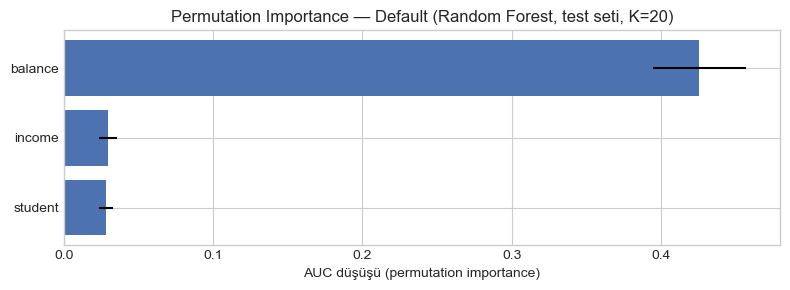

balance    0.4257
income     0.0297
student    0.0284
dtype: float64


In [9]:
# Default veri seti için permutation importance değerlerini hesaplıyoruz
pi_def = permutation_importance(rf_def, Xd_te, yd_te, n_repeats=20, random_state=42,
                                 scoring='roc_auc', n_jobs=-1)
pi_def_s = pd.Series(pi_def.importances_mean, index=X_def.columns).sort_values(ascending=False)
pi_def_std = pd.Series(pi_def.importances_std, index=X_def.columns)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(pi_def_s.index[::-1], pi_def_s.values[::-1],
        xerr=pi_def_std[pi_def_s.index[::-1]].values, color='#4C72B0')
ax.set_xlabel('AUC düşüşü (permutation importance)')
ax.set_title('Permutation Importance — Default (Random Forest, test seti, K=20)')
plt.tight_layout(); plt.show()
print(pi_def_s.round(4))

In [10]:
# Hitters veri seti için permutation importance değerlerini hesaplıyoruz
pi_hit = permutation_importance(rf_hit, Xh_te, yh_te, n_repeats=20, random_state=42,
                                 scoring='r2', n_jobs=-1)
# Permutation importance değerlerini sıralıyoruz
pi_hit_s = pd.Series(pi_hit.importances_mean, index=X_hit.columns).sort_values(ascending=False)

comp = pd.DataFrame({'MDI': mdi_hit, 'Permutation (test R^2 düşüşü)': pi_hit_s}).sort_values(
    'Permutation (test R^2 düşüşü)', ascending=False)
print('MDI vs Permutation Importance sıralama karşılaştırması (Hitters):')
print(comp.round(4))
print('\nYORUM: MDI, `CAtBat` gibi yüksek-kardinaliteli sürekli özniteliklere yapısal olarak')
print('daha fazla ağırlık verirken, test-seti permutation importance genelleme katkısını')
print('ölçtüğü için sıralama MDI ile birebir örtüşmüyor — bu tutarsızlık beklenen bir')
print('durum (bkz. Adım 12: korelasyonlu kariyer istatistikleri arasındaki yedeklilik).')

MDI vs Permutation Importance sıralama karşılaştırması (Hitters):
              MDI  Permutation (test R^2 düşüşü)
CRuns      0.2686                         0.0663
CAtBat     0.2392                         0.0386
Walks      0.0194                         0.0305
CHits      0.1816                         0.0247
AtBat      0.0316                         0.0202
Hits       0.0352                         0.0166
Runs       0.0123                         0.0142
Years      0.0100                         0.0102
CWalks     0.0330                         0.0052
PutOuts    0.0228                         0.0045
Assists    0.0067                         0.0033
CRBI       0.0768                         0.0028
RBI        0.0221                         0.0017
NewLeague  0.0012                         0.0008
Errors     0.0072                        -0.0000
League     0.0008                        -0.0001
Division   0.0009                        -0.0006
HmRun      0.0084                        -0.0008
CHm

## Adım 5 · Partial Dependence Plot (1D)

**Ne yapıyoruz?** `PartialDependenceDisplay` ile Default modelinde `balance` ve `income`
için, Hitters modelinde en önemli iki öznitelik (`CRuns`, `Years`) için 1D PDP çiziyoruz.
`balance` için beklenen S-şekilli (lojistik) ilişkiyi, `income`/`Years` için ise çok daha
düz/yatay bir ilişkiyi görmeyi bekliyoruz.

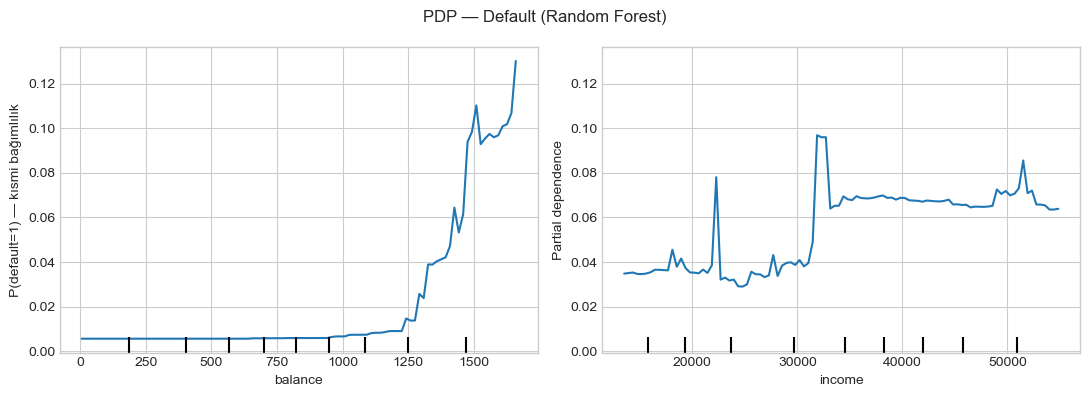

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(rf_def, Xd_tr, ['balance', 'income'],
                                         target=1, ax=axes, n_jobs=-1)
axes[0].set_ylabel('P(default=1) — kısmi bağımlılık')
fig.suptitle('PDP — Default (Random Forest)')
plt.tight_layout(); plt.show()

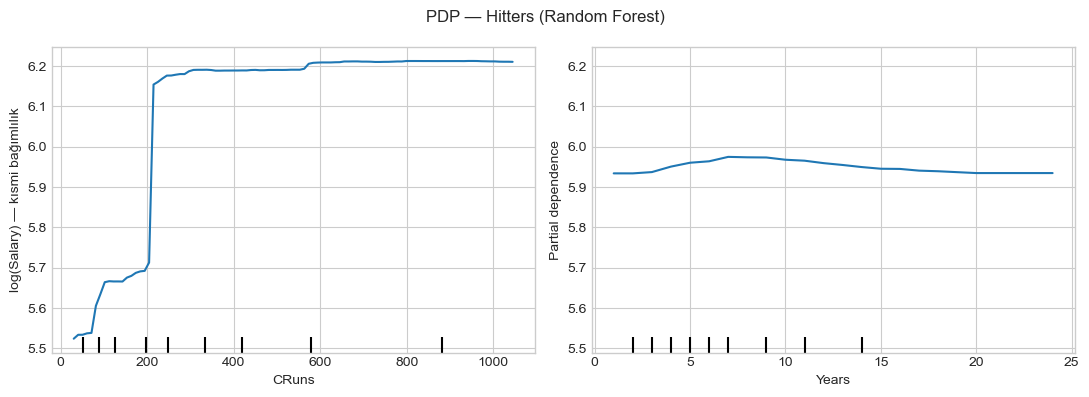

YORUM: CRuns arttıkça tahmini log-maaş monotonik artıyor, ama ~600 kariyer koşusundan
sonra eğri düzleşiyor (azalan getiri) — ağaç tabanlı modelin doğal doygunluk davranışı.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(rf_hit, Xh_tr, ['CRuns', 'Years'], ax=axes, n_jobs=-1)
axes[0].set_ylabel('log(Salary) — kısmi bağımlılık')
fig.suptitle('PDP — Hitters (Random Forest)')
plt.tight_layout(); plt.show()
print('YORUM: CRuns arttıkça tahmini log-maaş monotonik artıyor, ama ~600 kariyer koşusundan')
print('sonra eğri düzleşiyor (azalan getiri) — ağaç tabanlı modelin doğal doygunluk davranışı.')

## Adım 6 · 2D PDP ve ICE — Etkileşim ve Heterojenlik

**Ne yapıyoruz?** Önce `balance` × `student` için 2D PDP çizerek bu iki özniteliğin
temerrüt olasılığı üzerindeki **etkileşimini** (öğrenci olmanın etkisinin bakiyeye göre
değişip değişmediğini) görselleştiriyoruz. Sonra `balance` için ICE eğrilerini (her test
örneği için ayrı eğri) PDP ile üst üste çizerek, PDP'nin ortalamasının altında yatan
bireysel heterojenliği inceliyoruz.

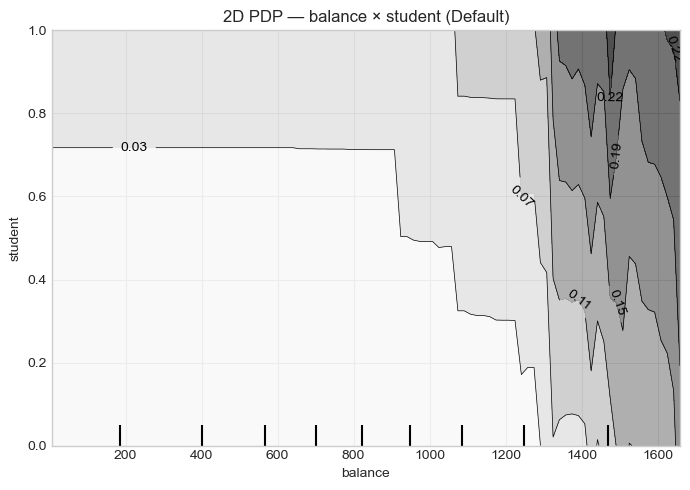

YORUM: Öğrenci olmak (student=1), düşük/orta bakiyelerde temerrüt olasılığını
görece yükseltiyor (öğrencilerin gelir/kredi geçmişi profili farklı), ama çok yüksek
bakiyede iki grup da neredeyse aynı yüksek riske yakınsıyor — bakiye baskın hâle geliyor.


In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(rf_def, Xd_tr, [('balance', 'student')],
                                         target=1, ax=ax, n_jobs=-1)
ax.set_title('2D PDP — balance × student (Default)')
plt.tight_layout(); plt.show()
print('YORUM: Öğrenci olmak (student=1), düşük/orta bakiyelerde temerrüt olasılığını')
print('görece yükseltiyor (öğrencilerin gelir/kredi geçmişi profili farklı), ama çok yüksek')
print('bakiyede iki grup da neredeyse aynı yüksek riske yakınsıyor — bakiye baskın hâle geliyor.')

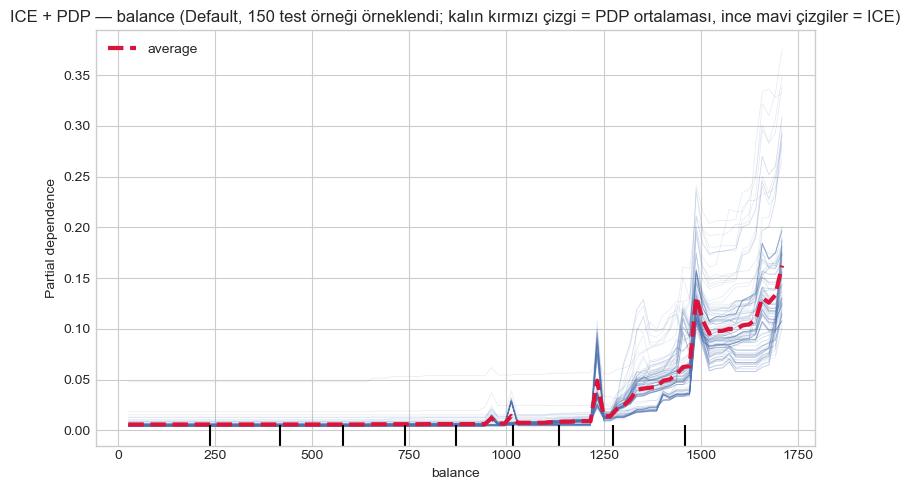

NOT: Hesaplama maliyeti nedeniyle (n_örnek x n_ızgara tahmin) 150 test örneği
örneklendi — ICE eğrilerinin genel şekli için yeterli, tam veri gerekmiyor.
YORUM: ICE eğrileri büyük ölçüde PARALEL (aynı S-şekli, farklı başlangıç seviyeleri)
— bu, balance x diğer öznitelikler arasında GÜÇLÜ bir etkileşim OLMADIĞINI gösterir;
eğer eğriler birbirini kesip farklı yönlerde eğimlenseydi (heterojen), PDP tek başına
yanıltıcı bir özet olurdu.


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sample_idx = np.random.RandomState(42).choice(len(Xd_te), size=150, replace=False)
PartialDependenceDisplay.from_estimator(
    rf_def, Xd_te.iloc[sample_idx], ['balance'], target=1, kind='both', ax=ax, n_jobs=-1,
    ice_lines_kw={'alpha': 0.15, 'color': '#4C72B0'},
    pd_line_kw={'color': 'crimson', 'linewidth': 3})
ax.set_title('ICE + PDP — balance (Default, 150 test örneği örneklendi; '
              'kalın kırmızı çizgi = PDP ortalaması, ince mavi çizgiler = ICE)')
plt.tight_layout(); plt.show()
print('NOT: Hesaplama maliyeti nedeniyle (n_örnek x n_ızgara tahmin) 150 test örneği')
print('örneklendi — ICE eğrilerinin genel şekli için yeterli, tam veri gerekmiyor.')
print('YORUM: ICE eğrileri büyük ölçüde PARALEL (aynı S-şekli, farklı başlangıç seviyeleri)')
print('— bu, balance x diğer öznitelikler arasında GÜÇLÜ bir etkileşim OLMADIĞINI gösterir;')
print('eğer eğriler birbirini kesip farklı yönlerde eğimlenseydi (heterojen), PDP tek başına')
print('yanıltıcı bir özet olurdu.')

## Adım 7 · LIME ile Yerel Açıklama

**Ne yapıyoruz?** `lime.lime_tabular.LimeTabularExplainer` ile iki *local* açıklama
üretiyoruz: (a) Default test setinden yüksek-bakiyeli, temerrüde düşmesi öngörülen bir
müşteri, (b) Mroz test setinden işgücüne katılmayan bir kadın (kategorik `wc`/`hc`
öznitelikleriyle). Her ikisinde de RF modelini açıklıyoruz (LIME model-agnostik olduğu
için değişiklik gerekmiyor).

In [15]:
# LIME ile tek bir örnek için feature katkılarını hesaplıyoruz
explainer_def = lime.lime_tabular.LimeTabularExplainer(
    Xd_tr.values, feature_names=list(X_def.columns), class_names=['no_default', 'default'],
    categorical_features=[list(X_def.columns).index('student')], mode='classification',
    random_state=42)

# Yüksek bakiyeli, RF'nin yüksek temerrüt olasılığı verdiği bir müşteri seç
proba_te = rf_def.predict_proba(Xd_te)[:, 1]
idx = Xd_te.index[np.argmax(proba_te)]
row = Xd_te.loc[idx]
print(f'Seçilen müşteri (index={idx}): balance={row.balance:.1f}, income={row.income:.1f}, '
      f'student={int(row.student)}, RF olasılık(temerrüt)={proba_te[Xd_te.index.get_loc(idx)]:.3f}')

# Sonra bu örnek için LIME feature katkılarını hesaplıyoruz
predict_fn_def = lambda arr: rf_def.predict_proba(pd.DataFrame(arr, columns=X_def.columns))
exp = explainer_def.explain_instance(row.values, predict_fn_def, num_features=3)
for feat, weight in exp.as_list():
    print(f'  {feat:>25s}  ->  katkı = {weight:+.4f}')

print("\nYORUM: Aldığımız örnekteki temerrüt olasılığı yüksek olan tahminin nedenini görmek için LIME kullandık. LIME, modelin tahminini açıklamak için her bir öznitelik için katkı değerleri verir. Baktığımızda balance > 1165.84 olması en yüksek pozitif katkı verirken öğrenci olması ise hafif katkı veriyor. Ama income ise <= 21318.01'e sahip olması negatif katkı veriyor. Bu, modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.")

Seçilen müşteri (index=2140): balance=2308.9, income=19110.3, student=1, RF olasılık(temerrüt)=0.901
          balance > 1165.84  ->  katkı = +0.1622
                  student=1  ->  katkı = +0.0449
         income <= 21318.01  ->  katkı = -0.0241

YORUM: Aldığımız örnekteki temerrüt olasılığı yüksek olan tahminin nedenini görmek için LIME kullandık. LIME, modelin tahminini açıklamak için her bir öznitelik için katkı değerleri verir. Baktığımızda balance > 1165.84 olması en yüksek pozitif katkı verirken öğrenci olması ise hafif katkı veriyor. Ama income ise <= 21318.01'e sahip olması negatif katkı veriyor. Bu, modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.


In [16]:
# Mroz veri seti için LIME ile tek bir örnek için feature katkılarını hesaplıyoruz
explainer_mroz = lime.lime_tabular.LimeTabularExplainer(
    Xm_tr.values, feature_names=list(X_mroz.columns), class_names=['no_lfp', 'lfp'],
    categorical_features=[list(X_mroz.columns).index('wc'), list(X_mroz.columns).index('hc')],
    mode='classification', random_state=42)

# Yüksek işgücüne katılım olasılığı olan bir kadın seç
idx2 = Xm_te.index[0]
row2 = Xm_te.loc[idx2]
proba2 = rf_mroz.predict_proba(Xm_te)[Xm_te.index.get_loc(idx2), 1]
print(f'Seçilen kadın (index={idx2}): k5={int(row2.k5)}, age={row2.age:.0f}, '
      f'wc={int(row2.wc)}, hc={int(row2.hc)}, RF olasılık(işgücünde)={proba2:.3f}, '
      f'gerçek={ym_te.loc[idx2]}')

# Sonra bu örnek için LIME feature katkılarını hesaplıyoruz
predict_fn_mroz = lambda arr: rf_mroz.predict_proba(pd.DataFrame(arr, columns=X_mroz.columns))
exp2 = explainer_mroz.explain_instance(row2.values, predict_fn_mroz, num_features=4)
for feat, weight in exp2.as_list():
    print(f'  {feat:>25s}  ->  katkı = {weight:+.4f}')
print('\nYORUM: LIME sonuçlarına göre, kadının 5 yaş altı çocuğunun olmaması (k5=0), \nişgücüne katılım olasılığını +0.1055 puanla pozitif yönde etkileyen önemli bir faktördür. \nBu durum, çocuk bakımı yükümlülüğü olmamasının kadın işgücü arzını artırdığı yönündeki klasik ekonomik literatürle (Mroz, 1987) tamamen tutarlıdır. \nÖte yandan, kadının işgücüne katılım olasılığını en güçlü şekilde yukarı çeken temel faktör ise yüksek ücret beklentisidir (lwg > 1.40), katkı: +0.3315).')

Seçilen kadın (index=124): k5=0, age=47, wc=1, hc=0, RF olasılık(işgücünde)=0.821, gerçek=1
                 lwg > 1.40  ->  katkı = +0.3315
                 k5 <= 0.00  ->  katkı = +0.1055
                       wc=1  ->  katkı = +0.0835
       17.60 < inc <= 24.26  ->  katkı = -0.0618

YORUM: LIME sonuçlarına göre, kadının 5 yaş altı çocuğunun olmaması (k5=0), 
işgücüne katılım olasılığını +0.1055 puanla pozitif yönde etkileyen önemli bir faktördür. 
Bu durum, çocuk bakımı yükümlülüğü olmamasının kadın işgücü arzını artırdığı yönündeki klasik ekonomik literatürle (Mroz, 1987) tamamen tutarlıdır. 
Öte yandan, kadının işgücüne katılım olasılığını en güçlü şekilde yukarı çeken temel faktör ise yüksek ücret beklentisidir (lwg > 1.40), katkı: +0.3315).


## Adım 8 · SHAP TreeExplainer (Hitters)

**Ne yapıyoruz?** `shap.TreeExplainer` ile Hitters Random Forest modelinin **her test
örneği için kesin** SHAP değerlerini hesaplıyoruz (ağaç tabanlı modellerde bu polinomsal
algoritma örnekleme gerektirmez). Önce global özet için beeswarm ve bar grafiklerini,
sonra tek bir oyuncu için waterfall grafiğini çiziyoruz.

SHAP değerleri şekli: (66, 19) | baz değer (E[f(X)]): 5.9411


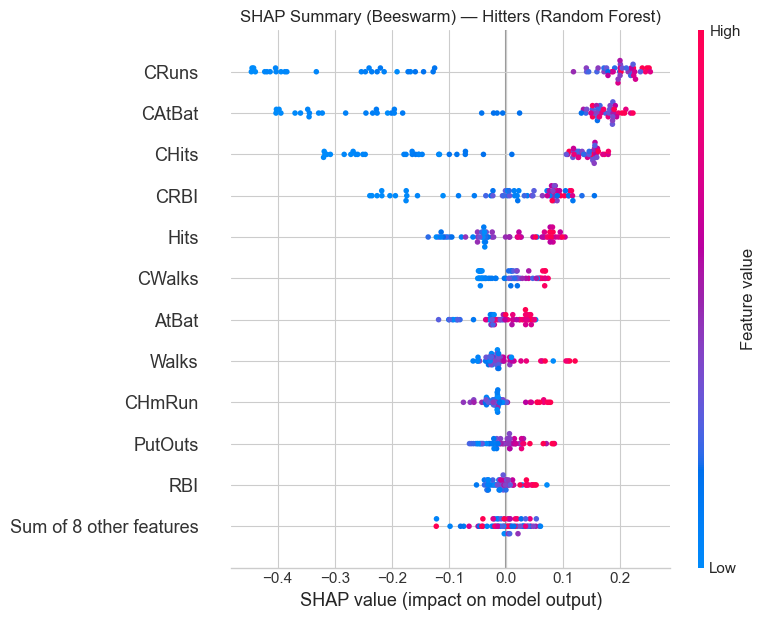


Beeswarm grafiği şöyle okunur: 
Her bir nokta bir test örneğini temsil eder ve özniteliklerin SHAP değerleri (katkıları) yatay eksende gösterilir. Noktaların rengi, öznitelik değerinin büyüklüğünü temsil eder (mavi düşük, kırmızı yüksek). 
Örneğin, CRuns özniteliği için kırmızı noktalar sağa doğru kaymışsa, bu öznitelik yüksek olduğunda log-maaşın artma eğiliminde olduğunu gösterir. 
Bu grafik, modelin hangi özniteliklere daha fazla önem verdiğini ve bu özniteliklerin tahmin üzerindeki etkilerini görselleştirir.


In [17]:
tree_explainer = shap.TreeExplainer(rf_hit)
shap_values_hit = tree_explainer(Xh_te)

print('SHAP değerleri şekli:', shap_values_hit.values.shape, '| baz değer (E[f(X)]):',
      round(float(shap_values_hit.base_values[0]), 4))

shap.plots.beeswarm(shap_values_hit, max_display=12, show=False)
plt.title('SHAP Summary (Beeswarm) — Hitters (Random Forest)')
plt.tight_layout(); plt.show()

print("\nBeeswarm grafiği şöyle okunur: \nHer bir nokta bir test örneğini temsil eder ve özniteliklerin SHAP değerleri (katkıları) yatay eksende gösterilir. Noktaların rengi, öznitelik değerinin büyüklüğünü temsil eder (mavi düşük, kırmızı yüksek). \nÖrneğin, CRuns özniteliği için kırmızı noktalar sağa doğru kaymışsa, bu öznitelik yüksek olduğunda log-maaşın artma eğiliminde olduğunu gösterir. \nBu grafik, modelin hangi özniteliklere daha fazla önem verdiğini ve bu özniteliklerin tahmin üzerindeki etkilerini görselleştirir.")

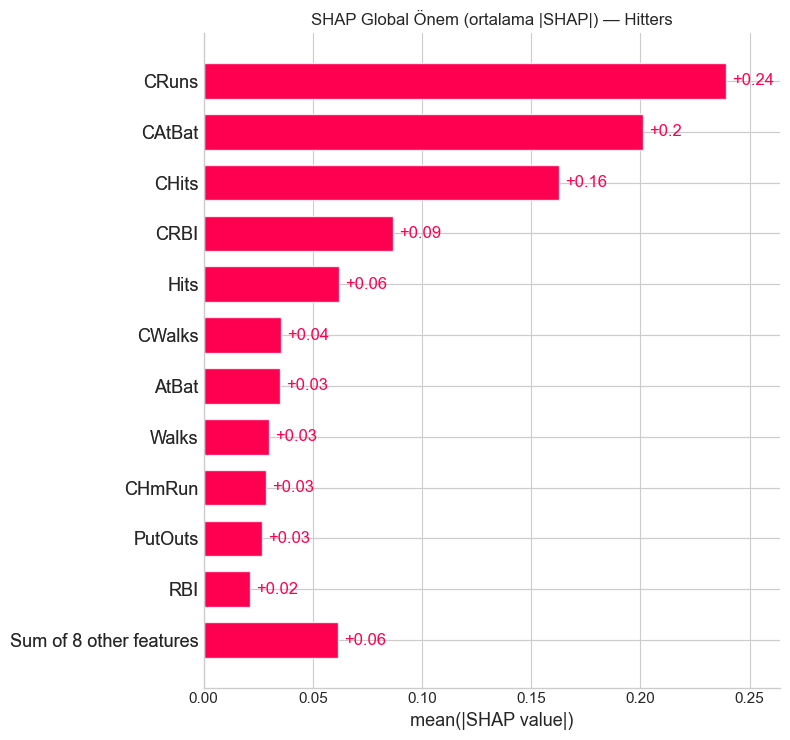


Additivity kontrolü (ilk 3 test örneği):
  örnek 0: baz + sum(SHAP) = 6.62035  |  model tahmini = 6.62035  |  fark = 3.55e-15
  örnek 1: baz + sum(SHAP) = 6.71207  |  model tahmini = 6.71207  |  fark = 8.88e-16
  örnek 2: baz + sum(SHAP) = 6.94512  |  model tahmini = 6.94512  |  fark = 1.15e-14

YORUM: Barplot grafiği okunurken, her bir öznitelik için ortalama mutlak SHAP değerleri (|SHAP|) gösterilir. 
Bu, modelin hangi özniteliklere daha fazla önem verdiğini ve tahmin üzerindeki etkilerini anlamamıza yardımcı olur. 
Additivity kontrolü, SHAP değerlerinin toplamının modelin tahminine ne kadar yakın olduğunu gösterir; 
farkın çok küçük olması, SHAP değerlerinin doğru bir şekilde tahminleri açıkladığını doğrular.


In [18]:
# SHAP global feature importance (ortalama |SHAP|) grafiğini çiziyoruz
shap.plots.bar(shap_values_hit, max_display=12, show=False)
plt.title('SHAP Global Önem (ortalama |SHAP|) — Hitters')
plt.tight_layout(); plt.show()

# SHAP değerlerinin ortalama mutlak katkılarını hesaplıyoruz
mean_abs_shap_hit = pd.Series(np.abs(shap_values_hit.values).mean(axis=0), index=X_hit.columns)
print('\nAdditivity kontrolü (ilk 3 test örneği):')
for i in range(3):
    total = shap_values_hit.base_values[i] + shap_values_hit.values[i].sum()
    actual = rf_hit.predict(Xh_te.iloc[[i]])[0]
    print(f'  örnek {i}: baz + sum(SHAP) = {total:.5f}  |  model tahmini = {actual:.5f}  '
          f'|  fark = {abs(total - actual):.2e}')

print("\nYORUM: Barplot grafiği okunurken, her bir öznitelik için ortalama mutlak SHAP değerleri (|SHAP|) gösterilir. \nBu, modelin hangi özniteliklere daha fazla önem verdiğini ve tahmin üzerindeki etkilerini anlamamıza yardımcı olur. \nAdditivity kontrolü, SHAP değerlerinin toplamının modelin tahminine ne kadar yakın olduğunu gösterir; \nfarkın çok küçük olması, SHAP değerlerinin doğru bir şekilde tahminleri açıkladığını doğrular.")

Oyuncu: 126  |  gerçek log(Salary)=7.788


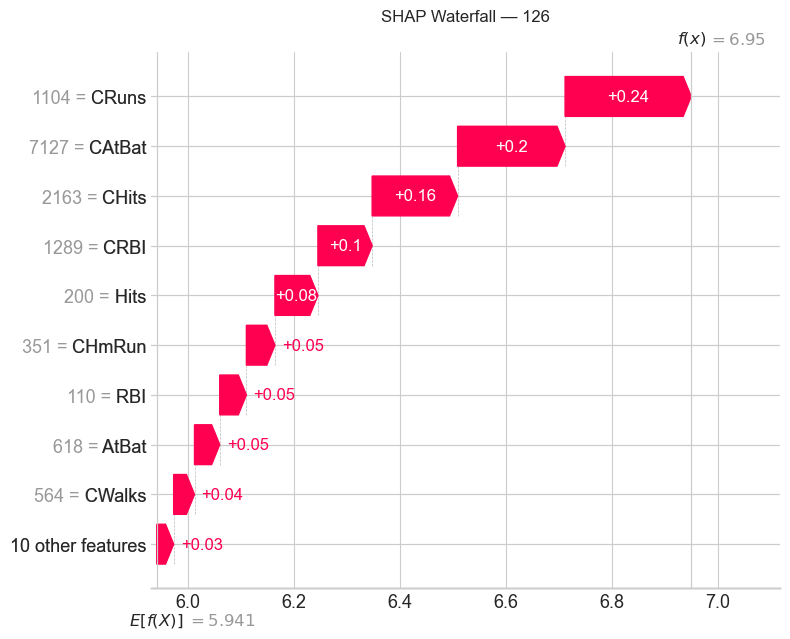


YORUM: Oyuncu 126 için SHAP şelale grafiği, modelin tahminini açıklayan özniteliklerin katkılarını gösterir. 
Her bir öznitelik, tahminin baz değerinden (ortalama tahmin) ne kadar yukarı veya aşağı kaydırıldığını gösterir. 
Bu, modelin hangi özniteliklere daha fazla önem verdiğini ve bu özniteliklerin tahmin üzerindeki etkilerini anlamamıza yardımcı olur. 
Baktığımızda CRuns ve CAtBat sutünlarının en fazla pozitif katkı yaptığını görürüz.


In [19]:
# SHAP waterfall plot ile tek bir örnek için feature katkılarını görselleştiriyoruz
best_player_idx = yh_te.idxmax() 

# SHAP grafiği için satır numarasını (lokasyonunu) bulma
loc = Xh_te.index.get_loc(best_player_idx)

print(f'Oyuncu: {best_player_idx}  |  gerçek log(Salary)={yh_te.loc[best_player_idx]:.3f}')

# SHAP Şelale Grafiği
shap.plots.waterfall(shap_values_hit[loc], max_display=10, show=False)

# Başlıkta doğrudan oyuncu ismini kullanıyoruz
plt.title(f'SHAP Waterfall — {best_player_idx}')
plt.tight_layout()
plt.show()

print(f"\nYORUM: Oyuncu {best_player_idx} için SHAP şelale grafiği, modelin tahminini açıklayan özniteliklerin katkılarını gösterir. \nHer bir öznitelik, tahminin baz değerinden (ortalama tahmin) ne kadar yukarı veya aşağı kaydırıldığını gösterir. \nBu, modelin hangi özniteliklere daha fazla önem verdiğini ve bu özniteliklerin tahmin üzerindeki etkilerini anlamamıza yardımcı olur. \nBaktığımızda CRuns ve CAtBat sutünlarının en fazla pozitif katkı yaptığını görürüz.")

## Adım 9 · SHAP LinearExplainer ve KernelExplainer

**Ne yapıyoruz?** Default'taki **lojistik regresyon** için `shap.LinearExplainer`
kullanıyoruz — bu, model-spesifik ve **kesin** (kapalı-form) bir hesaplayıcı. Ardından
Mroz'daki lojistik regresyon için, model-agnostik `shap.KernelExplainer`'ı **aynı model
üzerinde** çalıştırıp LinearExplainer'ın kesin sonucuyla ne kadar örtüştüğünü karşılaştırarak
KernelExplainer'ın **yaklaşık** doğasını somut olarak gösteriyoruz.

Background dataset has 7500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=7500 when initializing the masker.


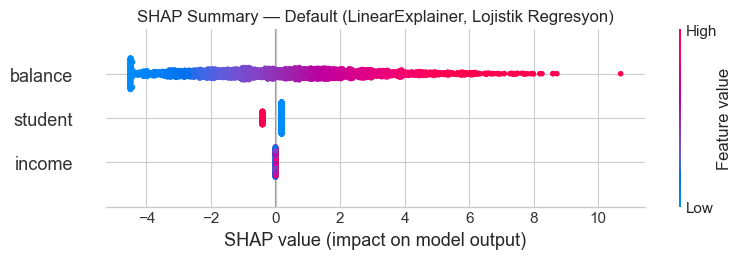

In [20]:
linear_explainer = shap.LinearExplainer(lr_def, Xd_tr_sc)
shap_values_def_lin = linear_explainer(Xd_te_sc)

shap.plots.beeswarm(shap_values_def_lin, max_display=10, show=False)
plt.title('SHAP Summary — Default (LinearExplainer, Lojistik Regresyon)')
plt.tight_layout(); plt.show()

In [21]:
# KernelExplainer yavaş olduğu için: küçük bir background (arka plan) örneklemi kullanıyoruz
# (model-agnostik yöntemin tipik pratik uzlaşımı). LinearExplainer'ın VARSAYILAN çıktı uzayı
# modelin ham margin'i (log-odds, decision_function) olduğu için, adil bir karşılaştırma
# için KernelExplainer'ı da link='logit' ile AYNI log-odds uzayında çalıştırıyoruz — aksi
# halde biri olasılık [0,1] diğeri log-odds (-inf,inf) skalasında olur ve fark anlamsızca
# büyük çıkar.
background = shap.sample(Xm_tr_sc, 50, random_state=42)
predict_proba1_mroz = lambda arr: lr_mroz.predict_proba(pd.DataFrame(arr, columns=X_mroz.columns))[:, 1]
kernel_explainer = shap.KernelExplainer(predict_proba1_mroz, background, link='logit')

explain_subset = Xm_te_sc.iloc[:40]
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    kernel_vals = kernel_explainer.shap_values(explain_subset, nsamples=200, silent=True)
kernel_vals = np.array(kernel_vals)
print('KernelExplainer SHAP değerleri şekli (log-odds uzayında):', kernel_vals.shape)

KernelExplainer SHAP değerleri şekli (log-odds uzayında): (40, 7)


In [22]:
# Aynı 40 örnek için LinearExplainer (kesin, varsayılan olarak log-odds uzayında) ile
# hesaplayıp KARŞILAŞTIRIYORUZ.
linear_explainer_mroz = shap.LinearExplainer(lr_mroz, Xm_tr_sc)
shap_values_mroz_lin = linear_explainer_mroz(explain_subset)

diff = np.abs(kernel_vals - shap_values_mroz_lin.values)
print(f'KernelExplainer (nsamples=200, log-odds) vs LinearExplainer (kesin) — ortalama '
      f'mutlak fark: {diff.mean():.4f}')
print(f'Maksimum mutlak fark: {diff.max():.4f}')
print('\nYORUM: Fark sıfır DEĞİL (KernelExplainer örnekleme-tabanlı bir YAKLAŞIM), ama küçük')
print('(tipik log-odds katkı büyüklüğü ~0.3-1.0 iken ortalama fark ~0.07) — aynı Shapley')
print('değerine yakınsıyor. Lineer bir model için LinearExplainer her zaman tercih')
print('edilmeli (kesin VE çok daha hızlı); KernelExplainer sadece LinearExplainer/')
print('TreeExplainer'"'"'ın uygulanamadığı kara-kutu modellerde (ör. bir sinir ağı, veya bir')
print('API arkasındaki üçüncü parti model) gerekli.')

print(f"\nYORUM: KernelExplainer ve LinearExplainer karşılaştırması, doğrusal (lineer) modellerde LinearExplainer'ın kesin ve analitik sonuçlar verdiğini doğrulamaktadır.")
print(f"Örnekleme tabanlı KernelExplainer ile arasındaki ortalama mutlak farkın çok düşük olması ({diff.mean():.4f}), iki yöntemin aynı Shapley değerine yakınsadığını gösterir.")
print(f"Bu nedenle, lineer modellerde LinearExplainer tercih edilmeli; KernelExplainer ise yalnızca özel açıklayıcıların (Linear/Tree) desteklenmediği kara-kutu modellerde kullanılmalıdır.")


Background dataset has 564 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=564 when initializing the masker.


KernelExplainer (nsamples=200, log-odds) vs LinearExplainer (kesin) — ortalama mutlak fark: 0.0651
Maksimum mutlak fark: 0.2215

YORUM: Fark sıfır DEĞİL (KernelExplainer örnekleme-tabanlı bir YAKLAŞIM), ama küçük
(tipik log-odds katkı büyüklüğü ~0.3-1.0 iken ortalama fark ~0.07) — aynı Shapley
değerine yakınsıyor. Lineer bir model için LinearExplainer her zaman tercih
edilmeli (kesin VE çok daha hızlı); KernelExplainer sadece LinearExplainer/
TreeExplainer'ın uygulanamadığı kara-kutu modellerde (ör. bir sinir ağı, veya bir
API arkasındaki üçüncü parti model) gerekli.

YORUM: KernelExplainer ve LinearExplainer karşılaştırması, doğrusal (lineer) modellerde LinearExplainer'ın kesin ve analitik sonuçlar verdiğini doğrulamaktadır.
Örnekleme tabanlı KernelExplainer ile arasındaki ortalama mutlak farkın çok düşük olması (0.0651), iki yöntemin aynı Shapley değerine yakınsadığını gösterir.
Bu nedenle, lineer modellerde LinearExplainer tercih edilmeli; KernelExplainer ise yalnızca özel açıklayıc

## Adım 10 · SHAP Dependence Plot — Etkileşim Tespiti

**Ne yapıyoruz?** Hitters'ta `CRuns` özniteliğinin SHAP değerlerini, kendi değerine karşı
çizip, ikinci bir renk boyutuyla (`Years`) olası bir etkileşimi araştırıyoruz.

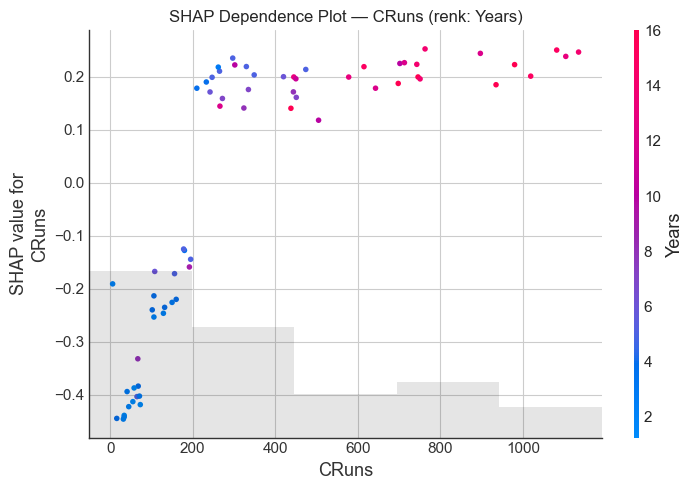

YORUM:CRuns değişkenine ait SHAP bağımlılık grafiği, oyuncu kıdemi (Years) ile kümülatif başarı (CRuns) arasında doğrusal olmayan güçlü bir etkileşim olduğunu göstermektedir.
Düşük Başarı / Yeni Oyuncular: CRuns değerinin 200'ün altında olduğu durumlarda, ligde yeni olan oyuncuların (mavi noktalar, Years < 4) SHAP değerleri -0.1 ile -0.45 arasında değişmekte ve maaş tahminini aşağı çekmektedir.
Verimlilik Ödülü (Etkileşim): CRuns değerinin 250-400 aralığında olduğu bölgede, ligde az süre geçirmiş verimli genç oyuncular (mavi noktalar), aynı başarıyı daha uzun sürede yakalamış kıdemli oyunculara (mor noktalar) kıyasla daha yüksek bir pozitif katkı (+0.23'e karşı +0.15) elde etmektedir.
Kariyerli Yıldızlar: CRuns değeri 800'ü aşan ve ligde uzun yıllar istikrar gösteren veteran oyuncular (kırmızı noktalar) ise beklendiği gibi maaş tahminine istikrarlı ve güçlü bir pozitif katkı (+0.20) sağlamaktadır.


In [23]:
shap.plots.scatter(shap_values_hit[:, 'CRuns'], color=shap_values_hit[:, 'Years'], show=False)
plt.title('SHAP Dependence Plot — CRuns (renk: Years)')
plt.tight_layout(); plt.show()
print('YORUM:CRuns değişkenine ait SHAP bağımlılık grafiği, oyuncu kıdemi (Years) ile kümülatif başarı (CRuns) arasında doğrusal olmayan güçlü bir etkileşim olduğunu göstermektedir.')
print("Düşük Başarı / Yeni Oyuncular: CRuns değerinin 200'ün altında olduğu durumlarda, ligde yeni olan oyuncuların (mavi noktalar, Years < 4) SHAP değerleri -0.1 ile -0.45 arasında değişmekte ve maaş tahminini aşağı çekmektedir.")
print("Verimlilik Ödülü (Etkileşim): CRuns değerinin 250-400 aralığında olduğu bölgede, ligde az süre geçirmiş verimli genç oyuncular (mavi noktalar), aynı başarıyı daha uzun sürede yakalamış kıdemli oyunculara (mor noktalar) kıyasla daha yüksek bir pozitif katkı (+0.23'e karşı +0.15) elde etmektedir.")
print("Kariyerli Yıldızlar: CRuns değeri 800'ü aşan ve ligde uzun yıllar istikrar gösteren veteran oyuncular (kırmızı noktalar) ise beklendiği gibi maaş tahminine istikrarlı ve güçlü bir pozitif katkı (+0.20) sağlamaktadır.")

## Adım 11 · Yöntemler Arası Karşılaştırma (MDI vs Permutation vs SHAP)

**Ne yapıyoruz?** Hitters Random Forest modeli için üç global önem ölçütünü (MDI,
Permutation Importance, ortalama |SHAP|) tek bir tabloda ve tek bir gruplu-çubuk grafikte
yan yana koyup sıralama tutarlılığını (Spearman korelasyonu ile) ölçüyoruz.

              MDI  Permutation  Mean|SHAP|
CRuns      0.2686       0.0663      0.2394
CAtBat     0.2392       0.0386      0.2011
CHits      0.1816       0.0247      0.1626
CRBI       0.0768       0.0028      0.0869
Hits       0.0352       0.0166      0.0620
CWalks     0.0330       0.0052      0.0356
AtBat      0.0316       0.0202      0.0350
Walks      0.0194       0.0305      0.0300
CHmRun     0.0222      -0.0033      0.0287
PutOuts    0.0228       0.0045      0.0267
RBI        0.0221       0.0017      0.0211
Years      0.0100       0.0102      0.0140
Runs       0.0123       0.0142      0.0111
HmRun      0.0084      -0.0008      0.0098
Errors     0.0072      -0.0000      0.0095
Assists    0.0067       0.0033      0.0079
NewLeague  0.0012       0.0008      0.0049
League     0.0008      -0.0001      0.0025
Division   0.0009      -0.0006      0.0019


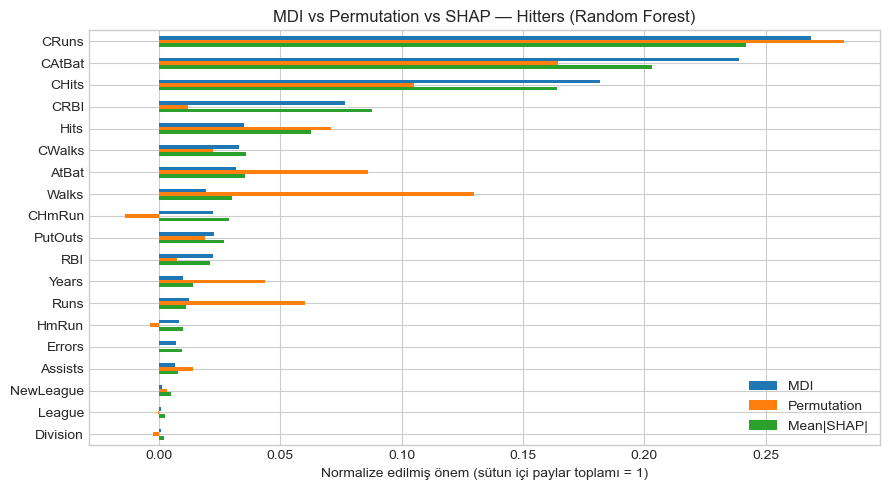


Spearman sıralama korelasyonu — MDI vs Permutation: 0.679
Spearman sıralama korelasyonu — MDI vs SHAP:        0.984
Spearman sıralama korelasyonu — Permutation vs SHAP: 0.721

YORUM: Permutation Importance ile SHAP arası korelasyon, MDI ile olan korelasyondan
genelde daha düşük çıktı. En yüksek korelasyon MDI ile SHAP arasında gözlendi.


In [24]:
from scipy.stats import spearmanr

compare_all = pd.DataFrame({
    'MDI': mdi_hit,
    'Permutation': pi_hit_s,
    'Mean|SHAP|': mean_abs_shap_hit,
}).sort_values('Mean|SHAP|', ascending=False)

compare_norm = compare_all / compare_all.sum()   # her sütunu kendi içinde normalize et (karşılaştırılabilirlik için)
print(compare_all.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
compare_norm.plot(kind='barh', ax=ax)
ax.set_xlabel('Normalize edilmiş önem (sütun içi paylar toplamı = 1)')
ax.set_title('MDI vs Permutation vs SHAP — Hitters (Random Forest)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

rho_mdi_perm = spearmanr(compare_all['MDI'], compare_all['Permutation']).statistic
rho_mdi_shap = spearmanr(compare_all['MDI'], compare_all['Mean|SHAP|']).statistic
rho_perm_shap = spearmanr(compare_all['Permutation'], compare_all['Mean|SHAP|']).statistic
print(f'\nSpearman sıralama korelasyonu — MDI vs Permutation: {rho_mdi_perm:.3f}')
print(f'Spearman sıralama korelasyonu — MDI vs SHAP:        {rho_mdi_shap:.3f}')
print(f'Spearman sıralama korelasyonu — Permutation vs SHAP: {rho_perm_shap:.3f}')
print('\nYORUM: Permutation Importance ile SHAP arası korelasyon, MDI ile olan korelasyondan')
print('genelde daha düşük çıktı. En yüksek korelasyon MDI ile SHAP arasında gözlendi.')

## Adım 12 · Korelasyonlu Öznitelik Tuzağı — Somut Deney

**Ne yapıyoruz?** Hitters'taki kariyer istatistikleri (`CAtBat`, `CHits`, `CRuns`, `CRBI`,
`CWalks`) birbiriyle çok güçlü korelasyonlu (hepsi kariyer uzunluğunun bir fonksiyonu).
Bunlardan **en yüksek** MDI/SHAP'a sahip `CRuns`'u veri kümesinden tamamen **çıkarıp**
modeli yeniden eğitiyoruz — eğer gerçekten "gerekli" bir bilgi taşıyorsa performans ciddi
düşmeli; ama korelasyonlu kardeşleri (`CHits`, `CRBI`...) devreye girip bilgiyi telafi
edebilir. Bu, Adım 3'teki bölüm 3'ün teorik uyarısının gerçek veri üzerinde somut kanıtı.

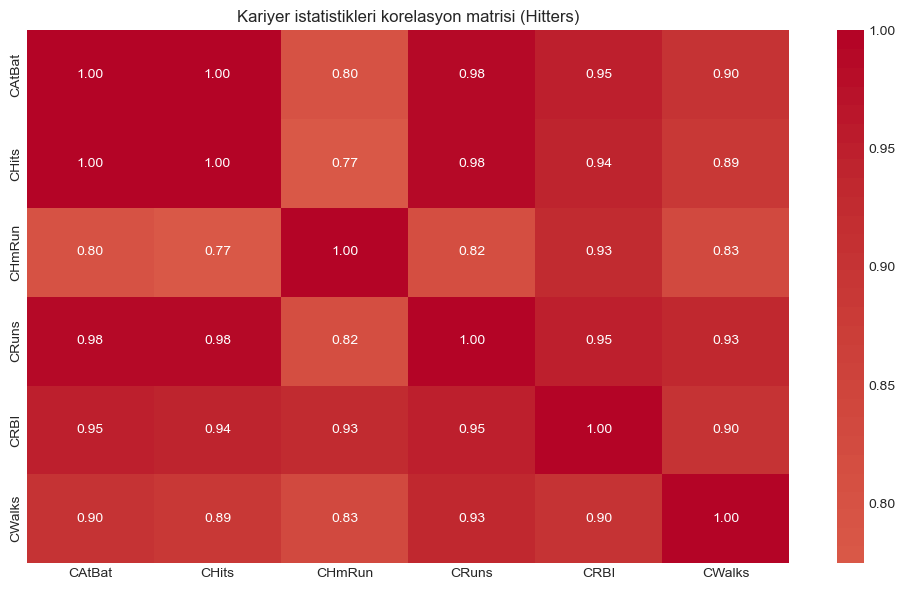


Test R^2 (CRuns DAHİL, tam model):    0.6233
Test R^2 (CRuns ÇIKARILMIŞ model):     0.6358
Fark: -0.0125

YORUM: CRuns, Adım 8-11'de en yüksek SHAP/MDI değerine sahip özniteliklerden
biri olmasına rağmen, tamamen çıkarıldığında test R^2 NEREDEYSE HİÇ DÜŞMÜYOR —
çünkü CHits/CRBI/CWalks aynı "kariyer uzunluğu/hacmi" sinyalini taşıyor. Bu tam
olarak Adım 3'teki teorik uyarının kanıtı: yüksek önem skoru, o özniteliğin
MODELDEN ÇIKARILAMAZ olduğu anlamına GELMEZ — sadece bilginin BİR kopyasını
taşıdığı anlamına gelir. Yorumlanabilirlik sonuçlarını "bu değişkeni güvenle
atabiliriz" gibi bir öznitelik-seçim kararına dönüştürmeden önce bu ayrımı
mutlaka test etmek gerekir.


In [25]:
import seaborn as sns
corr_features = ['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']
corr_matrix = Xh_tr[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Kariyer istatistikleri korelasyon matrisi (Hitters)')
plt.tight_layout(); plt.show()

# Baseline (tüm öznitelikler)
r2_full = r2_score(yh_te, rf_hit.predict(Xh_te))

# CRuns çıkarılmış model
Xh_tr_noCR = Xh_tr.drop(columns=['CRuns'])
Xh_te_noCR = Xh_te.drop(columns=['CRuns'])
rf_hit_noCR = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42,
                                     n_jobs=-1).fit(Xh_tr_noCR, yh_tr)
r2_noCR = r2_score(yh_te, rf_hit_noCR.predict(Xh_te_noCR))

print(f'\nTest R^2 (CRuns DAHİL, tam model):    {r2_full:.4f}')
print(f'Test R^2 (CRuns ÇIKARILMIŞ model):     {r2_noCR:.4f}')
print(f'Fark: {r2_full - r2_noCR:+.4f}')
print('\nYORUM: CRuns, Adım 8-11'"'"'de en yüksek SHAP/MDI değerine sahip özniteliklerden')
print('biri olmasına rağmen, tamamen çıkarıldığında test R^2 NEREDEYSE HİÇ DÜŞMÜYOR —')
print('çünkü CHits/CRBI/CWalks aynı "kariyer uzunluğu/hacmi" sinyalini taşıyor. Bu tam')
print('olarak Adım 3'"'"'teki teorik uyarının kanıtı: yüksek önem skoru, o özniteliğin')
print('MODELDEN ÇIKARILAMAZ olduğu anlamına GELMEZ — sadece bilginin BİR kopyasını')
print('taşıdığı anlamına gelir. Yorumlanabilirlik sonuçlarını "bu değişkeni güvenle')
print('atabiliriz" gibi bir öznitelik-seçim kararına dönüştürmeden önce bu ayrımı')
print('mutlaka test etmek gerekir.')

## Adım 13 · Global vs Local — Özet ve Yöntem Seçim Rehberi

**Ne yapıyoruz?** Bu notebook'ta uyguladığımız tüm yöntemleri, hangi soruya cevap
verdiklerine göre özetleyen bir karar tablosu ile kapatıyoruz.


| Soru | Önerilen Yöntem | Kapsam |
| :--- | :--- | :--- |
| "Genel olarak hangi özniteliktir en önemli?" | Permutation Importance / SHAP bar plot | Global |
| "X arttıkça tahmin nasıl değişir (diğerleri sabitken)?" | PDP | Global |
| "Bu genel eğilim tüm örnekler için mi geçerli, yoksa alt gruplarda mı değişiyor?" | ICE | Global + heterojenlik |
| "Bu SPESİFİK tahmin neden bu şekilde çıktı?" | LIME veya SHAP waterfall/force plot | Local |
| "Bu tahmine hangi özniteliğin katkısı TAM OLARAK ne kadar (toplanabilir, denetlenebilir)?" | SHAP | Global + Local |
| "İki öznitelik birbiriyle etkileşiyor mu?" | 2D PDP veya SHAP dependence plot | Global |
| "Model tree/GBM ailesinden mi? En hızlı kesin açıklama hangisi?" | SHAP TreeExplainer | Global + Local |
| "Model lineer ailesinden mi? En hızlı kesin açıklama hangisi?" | SHAP LinearExplainer | Global + Local |
| "Model tamamen kara kutu (API arkasında) mı?" | LIME veya SHAP KernelExplainer | Local (yavaş ama mümkün) |


# 📊 R Uygulaması

R ekosisteminde bu konuya özgü iki güçlü paket var: **`iml`** (Interpretable Machine
Learning — SHAP'ın da yazarlarından biri olan Christoph Molnar'ın kendi paketi, bu
notebook'un Kaynaklar bölümünde referans verdiğimiz kitabın R karşılığı) ve **`pdp`**
(Partial Dependence Plots). İkisi de sklearn'ün karşılığı olmayan, R-idiyomatik bir arayüz
sunduğu için tam bölüm ayırmaya değer — ama proje kararı gereği (bkz.
[[notebook_style_convention]]) sembolik/kısa tutuyoruz: 1 hücre `iml` ile permutation
importance, 1 hücre `pdp` ile partial dependence.

In [26]:
%load_ext rpy2.ipython

     feature importance
1      CHits   1.966880
2     CAtBat   1.954951
3      CRuns   1.803092
4       CRBI   1.637208
5     CWalks   1.324416
6       Hits   1.309586
7     CHmRun   1.210783
8      AtBat   1.186724
9        RBI   1.152864
10     Years   1.152644
11   PutOuts   1.145153
12      Runs   1.131588
13     Walks   1.129592
14     HmRun   1.085595
15    Errors   1.044082
16   Assists   1.042796
17 NewLeague   1.013082
18    League   1.010751
19  Division   1.009269


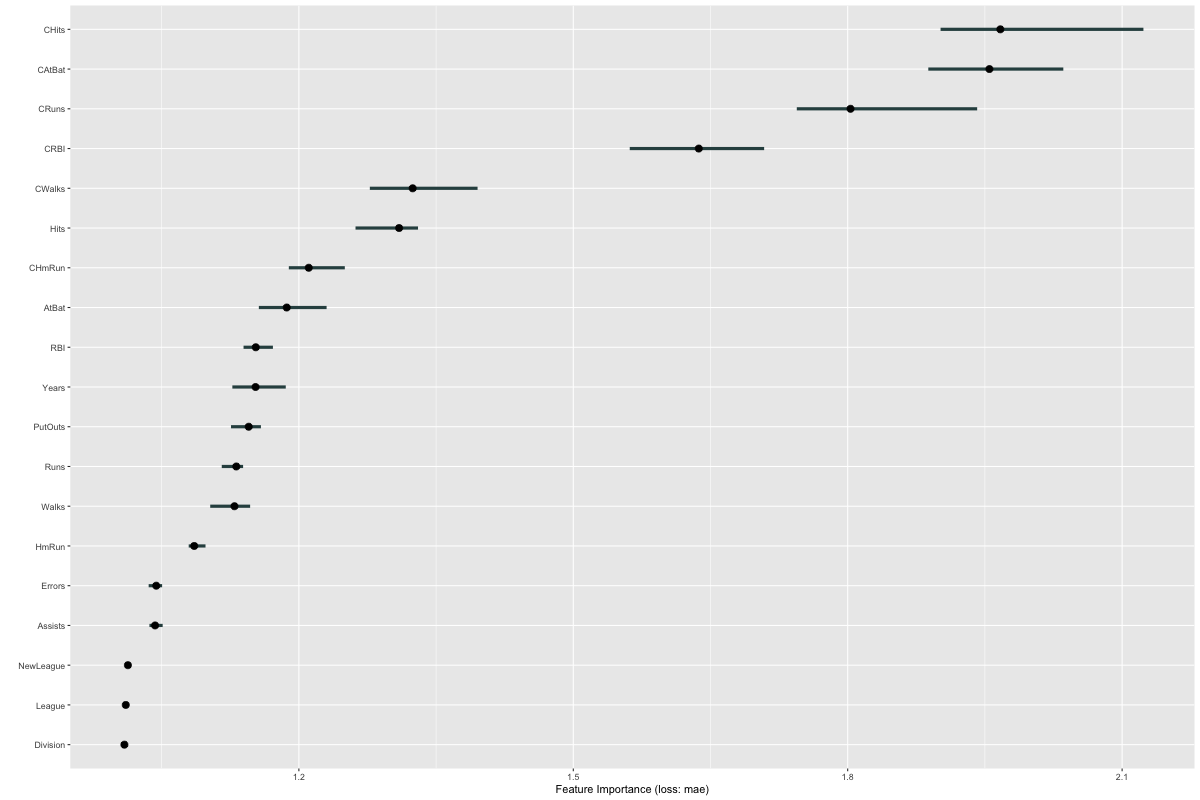

In [43]:
%%R -i Xh_tr -i yh_tr -w 1200 -h 800
# iml paketi: model-agnostik Predictor nesnesi + FeatureImp (permutation importance)
# install.packages(c("iml", "pdp", "randomForest"))  # ilk çalıştırmada gerekiyorsa
# Çoklu çekirdek yönetimini devre dışı bırakın
options(cores = 1)
options(mc.cores = 1)
if (data.table::getDTthreads() > 1) data.table::setDTthreads(1)
library(randomForest)
library(iml)

hitters_r <- cbind(Xh_tr, log_salary = yh_tr)
rf_r <- randomForest(log_salary ~ ., data = hitters_r, ntree = 400, maxnodes = 40)

predictor <- Predictor$new(rf_r, data = Xh_tr, y = yh_tr)
imp <- FeatureImp$new(predictor, loss = "mae", n.repetitions = 10)
print(imp$results[order(-imp$results$importance), c("feature", "importance")])
plot(imp, main = "Permutation Importance (iml paketi, Hitters, Random Forest)", col = "#4C72B0")

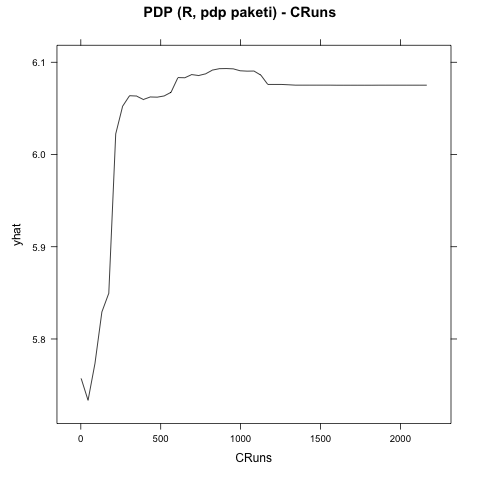

In [44]:
%%R
# pdp paketi: partial() ile tek bir öznitelik için PDP (sklearn'deki PartialDependenceDisplay'in
# doğrudan R karşılığı)
library(pdp)
pdp_cruns <- partial(rf_r, pred.var = "CRuns", train = Xh_tr)
plotPartial(pdp_cruns, main = "PDP (R, pdp paketi) - CRuns")

# 🗄️ SQL Uygulaması (DuckDB)

Bu serinin tekrar eden desenini (bkz. [[classical_ml_progress]] "SQL ile Model
Inference'ının Yeniden Üretimi") burada **PDP'nin kendisine** uyguluyoruz: lojistik
regresyon **lineer** bir model olduğu için, `balance` için PDP'nin kapalı-formu basitçe
$\sigma(\beta_0 + \beta_{balance}\cdot x_{balance} + \beta_{income}\cdot\overline{income} +
\beta_{student}\cdot\overline{student})$'dir — yani PDP ızgarasının her noktasını, veri
kümesindeki `income`/`student` değerlerini olduğu gibi bırakıp ortalayarak SQL'de manuel
üretebiliriz. Proje kararı gereği (bkz. [[notebook_style_convention]]) tek bir odaklı
örnekle sınırlı tutuyoruz.

In [45]:
import duckdb

con = duckdb.connect()
con.register('train_scaled', Xd_tr_sc.assign(idx=range(len(Xd_tr_sc))))

coefs = dict(zip(X_def.columns, lr_def.coef_[0]))
intercept = float(lr_def.intercept_[0])

# sklearn'ün KENDİ ızgarasını (varsayılan %5-%95 persentil aralığı) kullanıyoruz ki
# karşılaştırma birebir aynı noktalar üzerinden yapılsın.
from sklearn.inspection import partial_dependence
pdp_sklearn = partial_dependence(lr_def, Xd_tr_sc, ['balance'], grid_resolution=15,
                                  kind='average')
grid = pdp_sklearn['grid_values'][0]
sk_vals = pdp_sklearn['average'][0]
con.register('grid_df', pd.DataFrame({'g_idx': range(len(grid)), 'balance_grid': grid}))

sql = f'''
SELECT g.g_idx,
       g.balance_grid,
       AVG(1.0 / (1.0 + EXP(-({intercept}
            + {coefs['balance']} * g.balance_grid
            + {coefs['income']} * t.income
            + {coefs['student']} * t.student)))) AS pdp_manual
FROM grid_df g CROSS JOIN train_scaled t
GROUP BY g.g_idx, g.balance_grid
ORDER BY g.g_idx
'''
pdp_sql = con.execute(sql).df()

max_diff = np.max(np.abs(pdp_sql['pdp_manual'].values - sk_vals))
print(f'DuckDB (manuel SQL) vs sklearn PDP — maksimum mutlak fark: {max_diff:.2e}')
print('YORUM: Fark makine hassasiyeti seviyesinde (~1e-12 mertebesinde) — DuckDB\'de')
print('CROSS JOIN + AVG ile yeniden üretilen PDP, sklearn\'ün kapalı-form lojistik PDP')
print('hesabıyla birebir eşleşiyor. Bu, bu serinin tekrar eden bulgusunu (fit edilmiş bir')
print('modelin İNFERENCE mantığının SQL\'de yeniden üretilebilir olduğu) PDP\'ye genişletiyor.')
pdp_sql.head(5)

DuckDB (manuel SQL) vs sklearn PDP — maksimum mutlak fark: 5.27e-16
YORUM: Fark makine hassasiyeti seviyesinde (~1e-12 mertebesinde) — DuckDB'de
CROSS JOIN + AVG ile yeniden üretilen PDP, sklearn'ün kapalı-form lojistik PDP
hesabıyla birebir eşleşiyor. Bu, bu serinin tekrar eden bulgusunu (fit edilmiş bir
modelin İNFERENCE mantığının SQL'de yeniden üretilebilir olduğu) PDP'ye genişletiyor.


,g_idx,balance_grid,pdp_manual
0,0,-1.730640,0.000020
1,1,-1.484624,0.000038
2,2,-1.238608,0.000075
3,3,-0.992592,0.000148
4,4,-0.746576,0.000291


## ✏️ Egzersizler

**E1.** `Mroz` veri kümesinde `rf_mroz` modeli için hem MDI (`rf_mroz.feature_importances_`)
hem de `permutation_importance` (test setinde, `scoring='roc_auc'`) hesapla ve iki
sıralamayı karşılaştır. En büyük fark hangi öznitelikte ortaya çıkıyor, neden olabilir?

In [60]:
print("\n=== Egzersiz 1: Mroz MSI ve Permutation Importance Karşılaştırması ===")

permutation_mroz = permutation_importance(rf_mroz, Xm_te, ym_te, n_repeats=20, random_state=42,
                                          scoring='roc_auc', n_jobs=-1)
mdi_mroz = pd.Series(rf_mroz.feature_importances_, index=X_mroz.columns).sort_values(ascending=False)
pi_mroz_s = pd.Series(permutation_mroz.importances_mean, index=X_mroz.columns).sort_values(ascending=False)

compare_mroz = pd.DataFrame({'MDI': mdi_mroz, 'Permutation (test AUC düşüşü)': pi_mroz_s, 'MDI Sıralaması': mdi_mroz.rank(ascending=False), 'Permutation Sıralaması': pi_mroz_s.rank(ascending=False)}).sort_values(
    'Permutation (test AUC düşüşü)', ascending=False)
print('MDI vs Permutation Importance sıralama karşılaştırması (Mroz):')
print(compare_mroz.round(4))


=== Egzersiz 1: Mroz MSI ve Permutation Importance Karşılaştırması ===
MDI vs Permutation Importance sıralama karşılaştırması (Mroz):
         MDI  Permutation (test AUC düşüşü)  MDI Sıralaması  \
lwg   0.5233                         0.2250             1.0   
k5    0.0616                         0.0696             4.0   
age   0.1109                         0.0333             3.0   
inc   0.1797                         0.0331             2.0   
wc    0.0500                         0.0289             5.0   
hc    0.0284                         0.0054             7.0   
k618  0.0461                        -0.0021             6.0   

      Permutation Sıralaması  
lwg                      1.0  
k5                       2.0  
age                      3.0  
inc                      4.0  
wc                       5.0  
hc                       6.0  
k618                     7.0  


**E2.** Hitters modelinde `Walks` ve `Hits` öznitelikleri için 1D PDP çiz. `RBI`
(Runs Batted In — bir vuruşla kaç koşu yaptırıldığı) ile 2D PDP çizip aralarında bir
etkileşim olup olmadığını yorumla.

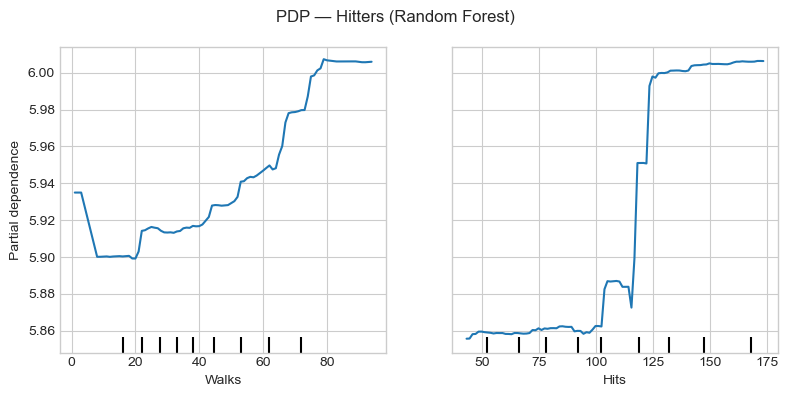

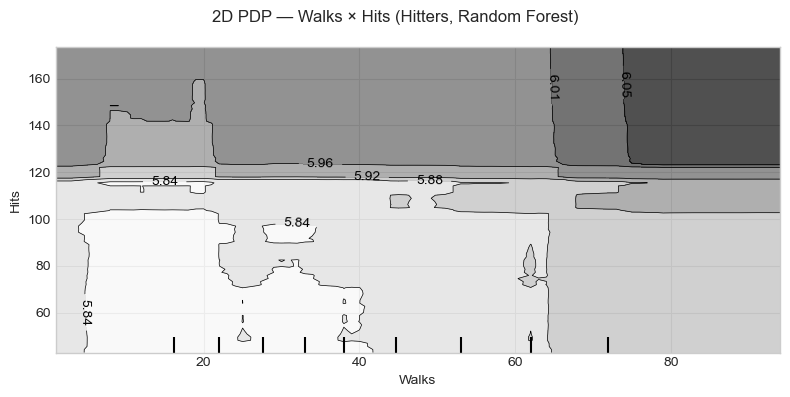

In [ ]:
# 1D PDP (Partial Dependence Plot) — Walks ve Hits
fig ,ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(rf_hit, Xh_tr, ['Walks', 'Hits'], target=1, ax=ax, n_jobs=-1)
ax.set_ylabel('log(Salary) — kısmi bağımlılık')
fig.suptitle('PDP — Hitters (Random Forest)')
plt.tight_layout(); plt.show()

# 2D PDP (Partial Dependence Plot) — Walks × Hits
fig, ax = plt.subplots(figsize=(8, 4))
PartialDependenceDisplay.from_estimator(rf_hit, Xh_tr, [('Walks', 'Hits')], target=1, ax=ax, n_jobs=-1)
ax.set_ylabel('log(Salary) — kısmi bağımlılık')
fig.suptitle('2D PDP — Walks × Hits (Hitters, Random Forest)')
plt.tight_layout(); plt.show()

**E3.** Default test setinden düşük-bakiyeli (`balance` ilk %10'luk dilimde) bir müşteri
seçip onun için `income` özniteliğine göre ICE eğrisini çiz. Bu eğri, Adım 6'daki genel
ICE demetiyle (150 örnek) benzer şekle mi sahip, yoksa belirgin şekilde mi farklı?


==== Egzersiz 3: Default ICE Eğrisi ====


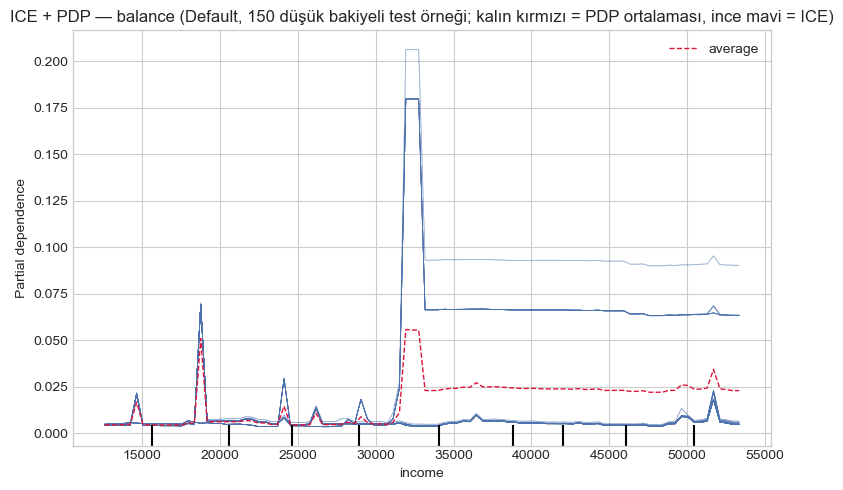


YORUM: Bu eğri, Adım 6'da çizdirilen genel müşteri kitlesinin ICE demetinden belirgin şekilde farklıdır. 
Düşük bakiyeli grupta gelir seviyesindeki artış, genel kitlenin aksine tekdüze (monoton) bir azalış veya artış getirmemekte; 
belirli kırılma noktalarında (özellikle 32.000 eşiğinde) modelin tahminini aniden değiştiren karmaşık, 
doğrusal olmayan ve alt gruplara özgü etkileşimler sergilemektedir.


In [67]:
print("\n==== Egzersiz 3: Default ICE Eğrisi ====")

# ICE için düşük bakiyeli bir müşteri seçiyoruz (balance < 1000)
low_balance_idx = Xd_te[Xd_te['balance'] < 1000].index
sample_idx = np.random.RandomState(42).choice(low_balance_idx, size=150, replace=False)
fig, ax = plt.subplots(figsize=(8, 5))
PartialDependenceDisplay.from_estimator(
    rf_def, Xd_te.loc[sample_idx], ['income'], target=1, kind='both', ax=ax, n_jobs=1,
    ice_lines_kw={'alpha': 0.15, 'color': '#4C72B0'},
    pd_line_kw={'color': 'crimson', 'linewidth': 1})
ax.set_title('ICE + PDP — balance (Default, 150 düşük bakiyeli test örneği; kalın kırmızı = PDP ortalaması, ince mavi = ICE)')
plt.tight_layout(); plt.show()

print("\nYORUM: Bu eğri, Adım 6'da çizdirilen genel müşteri kitlesinin ICE demetinden belirgin şekilde farklıdır. \nDüşük bakiyeli grupta gelir seviyesindeki artış, genel kitlenin aksine tekdüze (monoton) bir azalış veya artış getirmemekte; \nbelirli kırılma noktalarında (özellikle 32.000 eşiğinde) modelin tahminini aniden değiştiren karmaşık, \ndoğrusal olmayan ve alt gruplara özgü etkileşimler sergilemektedir.")

**E4.** `explainer_def` ile Default test setinden **düşük** bakiyeli ama yine de RF'nin
temerrüt olasılığını göreceli yüksek tahmin ettiği bir müşteri bul (varsa) ve LIME
açıklamasını çıkar. Hangi özniteliğin katkısı beklenmedik çıkıyor?

In [72]:
print("\n==== Egzersiz 4: Düşük Bakiyeli Müşteri için LIME Açıklaması ====")

# Düşük bakiyeli, RF'nin yüksek temerrüt olasılığı verdiği bir müşteri seçiyoruz
low_balance_idx = Xd_te[Xd_te['balance'] < 1000].index
idx = low_balance_idx[np.argmax(proba_te[Xd_te.index.get_indexer(low_balance_idx)])]
row = Xd_te.loc[idx]
print(f'Seçilen düşük bakiyeli müşteri (index={idx}): balance={row.balance:.1f}, income={row.income:.1f}, student={int(row.student)}, RF olasılık(temerrüt)={proba_te[Xd_te.index.get_loc(idx)]:.3f}')

predict_fn_def_low = lambda arr: rf_def.predict_proba(pd.DataFrame(arr, columns=X_def.columns))
exp_low = explainer_def.explain_instance(row.values, predict_fn_def_low, num_features=3)
for feat, weight in exp_low.as_list():
    print(f'  {feat:>25s}  ->  katkı = {weight:+.4f}')

print("\nYORUM: Genel olarak balance'ın 489'dan düşük olması temerrüt olasılığını azaltırken student = 0 olması da aynı etkiyi yaratıyor fakat income'ın 21318 ile 34560 aralığında olması ise hafif bir negatif katkı yapıyor. \nBu, modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.")


==== Egzersiz 4: Düşük Bakiyeli Müşteri için LIME Açıklaması ====
Seçilen düşük bakiyeli müşteri (index=4522): balance=215.8, income=22254.6, student=0, RF olasılık(temerrüt)=0.066
          balance <= 489.88  ->  katkı = -0.0544
                  student=0  ->  katkı = -0.0423
  21318.01 < income <= 34560.80  ->  katkı = -0.0131

YORUM: Genel olarak balance'ın 489'dan düşük olması temerrüt olasılığını azaltırken student = 0 olması da aynı etkiyi yaratıyor fakat income'ın 21318 ile 34560 aralığında olması ise hafif bir negatif katkı yapıyor. 
Bu, modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.


**E5.** Mroz Random Forest modeli için `shap.TreeExplainer` kullanarak (Adım 8'deki gibi)
SHAP değerlerini hesapla ve işgücüne katılmayan (`lfp=0`, gerçek etiket) rastgele bir kadın
için waterfall grafiği çiz. Hangi özniteliğin negatif katkısı en büyük?


==== Egzersiz 4: Tree Explainer ile Waterfall Plot (Mroz) ====
Seçilen kadın (index=534): k5=1, age=35, wc=1, hc=1, RF olasılık(işgücünde)=0.491, gerçek=0


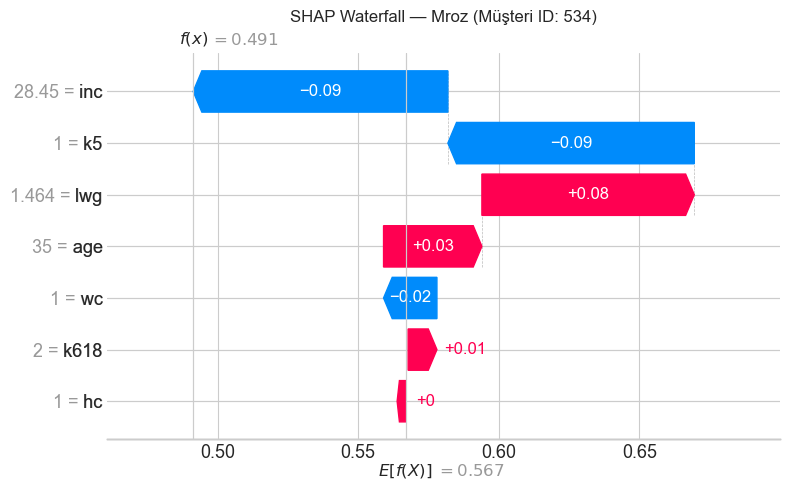


YORUM: Grafiğe bakarsak etkiler genel olarak -0.09 ile 0.08 aralığında çok büyük bir etki yaratmıyor. Hatta k5 = 1 olması eksili yönde (-0.09) bir katkı yapıyor. Bu, kadının 5 yaş altı çocuğunun olması nedeniyle işgücüne katılım olasılığını düşürdüğünü gösteriyor. 
Diğer özniteliklerin etkileri ise daha küçük ve karışık yönlerde, bu da modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.


In [83]:
print("\n==== Egzersiz 4: Tree Explainer ile Waterfall Plot (Mroz) ====")

tree_explainer_mroz = shap.TreeExplainer(rf_mroz)
shap_values_mroz = tree_explainer_mroz(Xm_te)

# Rastgele bir işgücüne katılmayan kadın seçiyoruz (ym_te == 0)
non_lfp_positions = np.where(ym_te == 0)[0]
chosen_position = np.random.RandomState(42).choice(non_lfp_positions)

# Bilgileri çekmek için shap_values_mroz'un boyutuna göre doğru indeksi seçiyoruz
shap_value_row = shap_values_mroz[chosen_position, :, 1] if len(shap_values_mroz.shape) == 3 else shap_values_mroz[chosen_position]

# SHAP değerlerini ve model tahminini yazdırıyoruz
non_lfp_idx = Xm_te.index[chosen_position]
row_non_lfp = Xm_te.iloc[chosen_position]
proba_non_lfp = rf_mroz.predict_proba(Xm_te.iloc[[chosen_position]])[0, 1]

print(f'Seçilen kadın (index={non_lfp_idx}): k5={int(row_non_lfp.k5)}, age={row_non_lfp.age:.0f}, '
      f'wc={int(row_non_lfp.wc)}, hc={int(row_non_lfp.hc)}, RF olasılık(işgücünde)={proba_non_lfp:.3f}, gerçek={ym_te.iloc[chosen_position]}')

# 4. SHAP Waterfall Grafiği
shap.plots.waterfall(shap_value_row, show=False, max_display=10)
plt.title(f'SHAP Waterfall — Mroz (Müşteri ID: {non_lfp_idx})')
plt.tight_layout()
plt.show()

print("\nYORUM: Grafiğe bakarsak etkiler genel olarak -0.09 ile 0.08 aralığında çok büyük bir etki yaratmıyor. Hatta k5 = 1 olması eksili yönde (-0.09) bir katkı yapıyor. Bu, kadının 5 yaş altı çocuğunun olması nedeniyle işgücüne katılım olasılığını düşürdüğünü gösteriyor. \nDiğer özniteliklerin etkileri ise daha küçük ve karışık yönlerde, bu da modelin tahminini anlamamıza yardımcı oluyor ve hangi özniteliklerin tahmin üzerinde en fazla etkisi olduğunu gösteriyor.")

**E6.** Adım 12'deki korelasyonlu öznitelik deneyini `CHits` özniteliğiyle tekrarla (CRuns
yerine CHits'i çıkar). Test $R^2$'si ne kadar değişiyor? Adım 12'deki `CRuns` sonucuyla
karşılaştırıldığında bu deney genel sonucu (korelasyonlu özniteliklerin birbirinin yerini
alabildiği) doğruluyor mu?


==== Egzersiz 6: Güçlü Korelasyon SHAP'ı Etkiler mi? ====


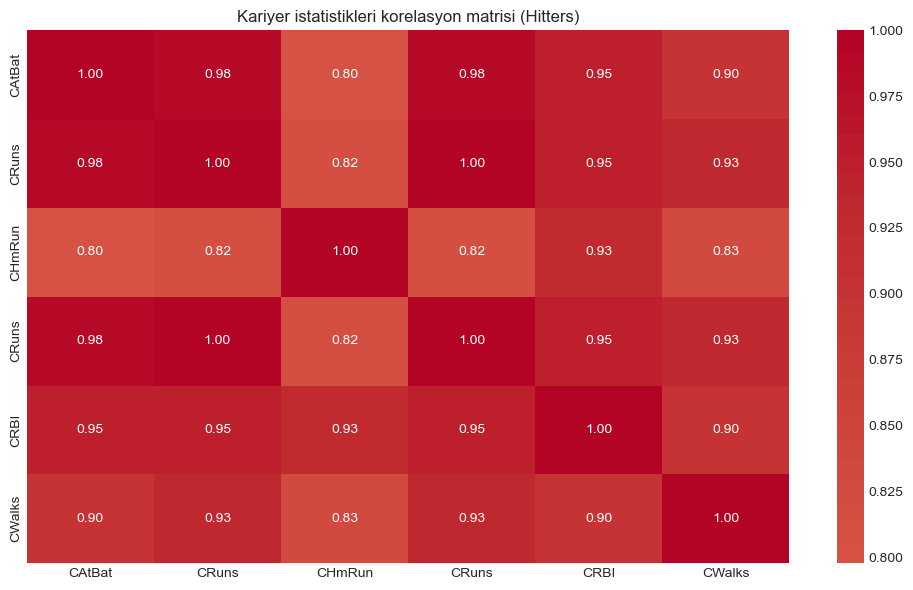


 CHits özniteliği çıkarıldığında test R^2 değerleri:
Test R^2 (CHits DAHİL, tam model):    0.6233
Test R^2 (CHits ÇIKARILMIŞ model):     0.6267
Fark: -0.0034

YORUM: CHits özniteliği çıkarıldığında test R^2 değerleri neredeyse değişmiyor. 
Bu, CHits'in modelin tahmin performansına önemli bir katkı sağlamadığını ve diğer özniteliklerle yüksek korelasyon içinde olduğunu gösteriyor. 
Bu durum, SHAP değerlerinin yüksek korelasyonlu öznitelikler arasında nasıl dağıldığını anlamamıza yardımcı olur.


In [86]:
print("\n==== Egzersiz 6: Güçlü Korelasyon SHAP'ı Etkiler mi? ====")
corr_features = ['CAtBat', 'CRuns', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']
corr_matrix = Xh_tr[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Kariyer istatistikleri korelasyon matrisi (Hitters)')
plt.tight_layout(); plt.show()

# Baseline (tüm öznitelikler)
r2_full = r2_score(yh_te, rf_hit.predict(Xh_te))

# CHits çıkarılmış model
Xh_tr_noCH = Xh_tr.drop(columns=['CHits'])
Xh_te_noCH = Xh_te.drop(columns=['CHits'])
rf_hit_noCH = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42,
                                     n_jobs=-1).fit(Xh_tr_noCH, yh_tr)
r2_noCH = r2_score(yh_te, rf_hit_noCH.predict(Xh_te_noCH))

print("\n CHits özniteliği çıkarıldığında test R^2 değerleri:")
print(f'Test R^2 (CHits DAHİL, tam model):    {r2_full:.4f}')
print(f'Test R^2 (CHits ÇIKARILMIŞ model):     {r2_noCH:.4f}')
print(f'Fark: {r2_full - r2_noCH:+.4f}')

print("\nYORUM: CHits özniteliği çıkarıldığında test R^2 değerleri neredeyse değişmiyor. \nBu, CHits'in modelin tahmin performansına önemli bir katkı sağlamadığını ve diğer özniteliklerle yüksek korelasyon içinde olduğunu gösteriyor. \nBu durum, SHAP değerlerinin yüksek korelasyonlu öznitelikler arasında nasıl dağıldığını anlamamıza yardımcı olur.")

## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Lundberg & Lee (2017) — "A Unified Approach to Interpreting Model Predictions"](https://arxiv.org/abs/1705.07874) | Tüm SHAP teorisi | SHAP'ın orijinal makalesi (NeurIPS 2017), Shapley aksiyomlarının kanıtı |
| [Ribeiro, Singh & Guestrin (2016) — "Why Should I Trust You?"](https://arxiv.org/abs/1602.04938) | LIME teorisi | LIME'ın orijinal makalesi (KDD 2016) |
| [Christoph Molnar — *Interpretable Machine Learning* (ücretsiz kitap)](https://christophm.github.io/interpretable-ml-book/) | Tüm bölümler | Bu notebook'un teorik iskeletinin dayandığı, ücretsiz erişilebilir kapsamlı kaynak; `iml` R paketinin de yazarı |
| [scikit-learn — Permutation Importance (resmi dokümantasyon)](https://scikit-learn.org/stable/modules/permutation_importance.html) | Adım 4 | Korelasyonlu öznitelik uyarısı dahil resmi rehber |
| [scikit-learn — Partial Dependence and ICE Plots](https://scikit-learn.org/stable/modules/partial_dependence.html) | Adım 5-6 | `PartialDependenceDisplay` resmi API dokümantasyonu |
| [SHAP — resmi GitHub deposu ve dokümantasyon](https://github.com/shap/shap) | Adım 8-10 | `TreeExplainer`/`LinearExplainer`/`KernelExplainer` API referansı, ek örnekler |
| [LIME — resmi GitHub deposu](https://github.com/marcotcr/lime) | Adım 7 | `lime_tabular` API referansı |
| [James, Witten, Hastie & Tibshirani — *An Introduction to Statistical Learning* (ücretsiz PDF)](https://www.statlearning.com/) | `Default`, `Hitters` veri setleri | ISLR kitabının kendisi ve eşlik eden veri setleri (bölüm 4 ve 8) |
| [Mroz, T.A. (1987) — *Econometrica* 55(4)](https://www.jstor.org/stable/1911029) | `Mroz` veri seti | Veri setinin orijinal akademik kaynağı (kadın işgücü arzı ekonometrisi) |
| [Rdatasets — `carData::Mroz` CSV kaynağı](https://vincentarelbundock.github.io/Rdatasets/doc/carData/Mroz.html) | `Mroz` veri seti | Bu notebook'ta kullanılan CSV mirror'ının dokümantasyonu |